# Integrated energy grids - Multi-country

## Imports

In [1]:
# Imports
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt
from datetime import timedelta
import os
from pathlib import Path
import gurobipy as gp
from gurobipy import GRB
import sys
import importlib
from IPython.display import display

pd.options.display.width = 120

print('pandas', pd.__version__, 'numpy', np.__version__)

pandas 3.0.2 numpy 2.4.3


## Data collection

### Folder Setup

In [2]:
# List files in current directory
print("Current directory:", os.getcwd())
print("\nFiles in workspace:")
for file in os.listdir('.'):
    print(f"  {file}")

Current directory: d:\descragass\DTU\Integrated Energy Grids\Prueba\Integrated-energy-grids-Assignment

Files in workspace:
  .git
  python_codes
  IEG_Course_Project_Part1.pdf
  Data
  Plots
  README.md
  back-up projects
  IEG_Assignment_Multi_country.ipynb
  IEG_Assignment_Single_country.ipynb
  IEG_Course_Project_Part2.pdf
  IEG_Interannual_Variability.ipynb
  IEG_Electricity_H2_network.ipynb
  IEG_Electricity_H2_network_&_Heat.ipynb


### CSV loading

- **Installed Capacity**
- **Hourly operating program**
- **Daily gas price**

In [3]:
# --- 1) Load CSV data (workspace files) ---
base = Path('./Data')
cap_file = base / 'export_InstalledCapacityGenerationTotal_2026-03-03_17_12.csv'
hourly_file = base / 'export_OperatingHourlyProgramGeneration+Storage+BalearicHVDCLinkP48_2026-03-03_17_22.csv'
gas_file = base / 'Gas prices Spain 2025.csv'

# Read installed capacities
cap_df = pd.read_csv(cap_file, sep=';')
cap_df = cap_df.rename(columns={'name':'tech','value':'capacity','start_date':'start','end_date':'end'})
print('installed capacities rows:', len(cap_df))
display(cap_df.head())

# Read hourly operating program (we treat 'value' as system demand/required generation)
hourly_df = pd.read_csv(hourly_file, sep=';')
hourly_df['datetime'] = pd.to_datetime(hourly_df['datetime'], utc=True)
hourly_df = hourly_df.set_index('datetime').sort_index()
print('hourly rows:', len(hourly_df))
display(hourly_df.head(3))

# Read gas price (daily)
gas_df = pd.read_csv(gas_file, sep=';', header=0)
# Clean up columns and decimals
gas_df.columns = [c.strip('"') for c in gas_df.columns]
gas_df['Delivery Day'] = pd.to_datetime(gas_df['Delivery Day'].str.strip('"'), dayfirst=True)
gas_df['MIBGAS-ES Index'] = gas_df['MIBGAS-ES Index'].astype(str).str.replace(',', '.').astype(float)
gas_df = gas_df.set_index('Delivery Day')['MIBGAS-ES Index']
display(gas_df.head(3))

installed capacities rows: 27


,id,tech,geoid,geoname,capacity,start,end
0,1478,Installed capacity generation coal,NaN,NaN,241.200,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
1,1478,Installed capacity generation coal,NaN,NaN,570.050,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
2,1478,Installed capacity generation coal,NaN,NaN,1249.925,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
3,1483,Installed capacity generation combined cycle GT,NaN,NaN,26250.145,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00
4,1489,Installed capacity generation cogeneration,NaN,NaN,5622.455,2024-03-01T00:00:00+01:00,2024-03-31T23:55:00+02:00


hourly rows: 188498


,id,name,geoid,geoname,value
datetime,,,,,
2023-12-31 23:00:00+00:00,10024,Operating Hourly Program Generation + storage ...,NaN,NaN,21453.375
2023-12-31 23:00:00+00:00,92,Operating Hourly Program P48 Biogas,NaN,NaN,82.500
2023-12-31 23:00:00+00:00,91,Operating Hourly Program P48 Biomass,NaN,NaN,207.600


C:\Users\ccano\AppData\Local\Temp\ipykernel_6224\2052013660.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gas_df['Delivery Day'] = pd.to_datetime(gas_df['Delivery Day'].str.strip('"'), dayfirst=True)


Delivery Day
2025-03-03    46.23
2025-03-04    44.69
2025-03-05    43.07
Name: MIBGAS-ES Index, dtype: float64

**Compilation of installed capacity**

In [4]:
# --- 2) Compile capacities by technology ---
cap_by_tech = cap_df.groupby('tech', dropna=False)['capacity'].sum().to_frame()
# Map long names to short technology keys (edit mapping as needed)
tech_map = {
    'Installed capacity generation combined cycle GT': 'CCGT',
    'Installed capacity generation coal': 'Coal',
    'Installed capacity generation nuclear': 'Nuclear',
    'Installed capacity generation wind': 'Wind',
    'Installed capacity generation hydro': 'Hydro',
    'Installed capacity generation solar': 'Solar',
    'Installed capacity generation solar PV': 'Solar',
    'Installed capacity generation solar thermal': 'Solar',
    'Installed capacity generation diesel engines': 'Diesel',
    'Installed capacity generation cogeneration': 'CHP',
    'Installed capacity generation other renewables': 'OtherRenew'
}
tech_caps = {}
for longname, cap in cap_by_tech['capacity'].items():
    key = tech_map.get(longname, longname)
    tech_caps[key] = tech_caps.get(key, 0.0) + float(cap)

# Filter to only Wind, Solar, and Hydro
tech_caps = {k: v for k, v in tech_caps.items() if k in ['Wind', 'Solar', 'Hydro']}
tech_caps = pd.Series(tech_caps).sort_values(ascending=False)
print('Aggregated technology capacities (MW):')
display(tech_caps)

Aggregated technology capacities (MW):


Solar    33947.119
Wind     31020.198
Hydro    17096.959
dtype: float64

**Hourly Demand Set-up**

In [5]:
# --- 3) Prepare hourly demand and hourly gas price series ---
demand = hourly_df['value'].rename('demand')
# Expand daily gas price to hourly (forward-fill)
# build hourly index covering demand range
hour_index = pd.date_range(start=demand.index[0].floor('D'), end=demand.index[-1].ceil('D') - timedelta(hours=1), freq='h')
print('demand range:', demand.index.min(), 'to', demand.index.max())
display(demand.head())

demand range: 2023-12-31 23:00:00+00:00 to 2024-12-31 22:00:00+00:00


datetime
2023-12-31 23:00:00+00:00    21453.375
2023-12-31 23:00:00+00:00       82.500
2023-12-31 23:00:00+00:00      207.600
2023-12-31 23:00:00+00:00        2.800
2023-12-31 23:00:00+00:00     3341.100
Name: demand, dtype: float64

**Generation by technology dataframe creation**

In [6]:
# Read full hourly file (raw multiple technologies)
df_raw = pd.read_csv(hourly_file, sep=';')
# parse datetimes
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'], utc=True)

# helper to simplify long technology names
def simplify_name(n: str) -> str:
    # handle NaN or non-string
    if pd.isna(n):
        return 'Other'
    s = str(n).lower().strip()
    if not s:
        return 'Other'
    # Remove common prefixes/words that add noise
    for drop in ['operating hourly program', 'operating hourly program generation', 'operating hourly program p48', 'operating hourly program p48 ', 'p48', 'balearic', 'hvdc link', '+', '/', '\\n']:
        s = s.replace(drop, ' ')
    s = ' '.join(s.split())
    # mapping by keywords
    if 'hydro' in s:
        return 'Hydro'
    if 'wind' in s:
        return 'Wind'
    if 'solar' in s or 'pv' in s:
        return 'Solar'
    if 'coal' in s:
        return 'Coal'
    if 'nuclear' in s:
        return 'Nuclear'
    if 'combined cycle' in s or 'ccgt' in s or 'combined' in s:
        return 'CCGT'
    if 'diesel' in s or 'diesel engines' in s:
        return 'Diesel'
    if 'cogeneration' in s or 'chp' in s:
        return 'CHP'
    if 'storage' in s or 'battery' in s or 'pumping' in s or 'turbine pumping' in s or 'pump' in s:
        return 'Storage'
    if 'hvdc' in s or 'link' in s:
        return 'HVDC'
    if 'waste' in s:
        return 'Waste'
    if 'other' in s or 'renew' in s:
        return 'OtherRenew'
    # fallback: take first meaningful token
    toks = [t for t in s.split() if any(c.isalpha() for c in t)]
    if toks:
        tok = toks[0]
        return tok.capitalize()
    return 'Other'

# Apply simplification
if 'name' not in df_raw.columns:
    df_raw['name'] = 'Unknown'

df_raw['tech'] = df_raw['name'].apply(simplify_name)

# Keep only relevant columns
df_small = df_raw[['datetime', 'tech', 'value']].copy()
# convert value to numeric
df_small['value'] = pd.to_numeric(df_small['value'], errors='coerce').fillna(0.0)

# Pivot: index=datetime, columns=tech, aggregate by sum (some hours may have multiple rows per tech)
gen_by_tech = df_small.pivot_table(index='datetime', columns='tech', values='value', aggfunc='sum')

# drop storage column entirely if present
if 'Storage' in gen_by_tech.columns:
    gen_by_tech = gen_by_tech.drop(columns=['Storage'])

# ensure nonÃƒÂ¢Ã¢â€šÂ¬Ã¢€Ëœnegative
gen_by_tech = gen_by_tech.clip(lower=0)

# Ensure full hourly index covering the range of 2024 data present in CSV
full_index = pd.date_range(start=gen_by_tech.index.min().floor('D'), end=gen_by_tech.index.max().ceil('D') - pd.Timedelta(hours=1), freq='h')
gen_by_tech = gen_by_tech.reindex(full_index).fillna(0.0)
# set name for index
gen_by_tech.index.name = 'datetime'

# add demand column equal to sum of technologies (excluding negative values)
gen_by_tech['demand'] = gen_by_tech.clip(lower=0).sum(axis=1)

print('Generated DataFrame `gen_by_tech` with shape:', gen_by_tech.shape)
display(gen_by_tech.head())

# Save to csv for later use
gen_by_tech.to_csv('./Data/generation_by_tech_2024.csv')


Generated DataFrame `gen_by_tech` with shape: (8808, 18)


tech,Biogas,Biomass,CCGT,CHP,Coal,Fossil,Generic,Hydro,Mining,Nuclear,Other,OtherRenew,Residual,Scheduled,Solar,Waste,Wind,demand
datetime,,,,,,,,,,,,,,,,,,
2023-12-31 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 02:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 03:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-31 04:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Sample week**

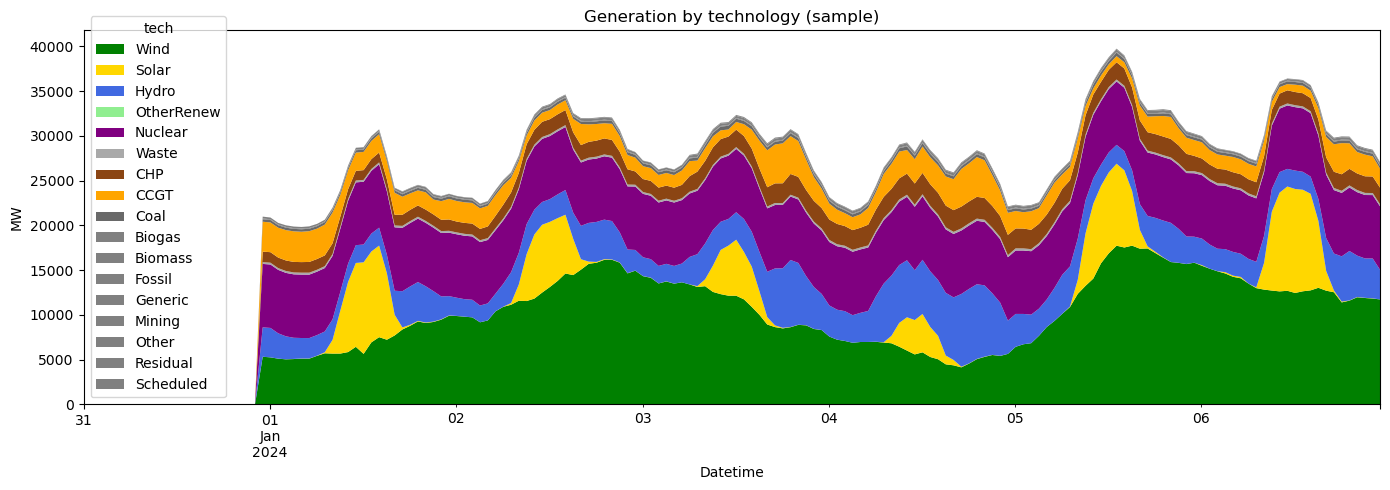

In [7]:
# --- Plot `gen_by_tech` (stacked area) ---
import matplotlib.pyplot as plt

if 'gen_by_tech' not in globals():
    raise RuntimeError('`gen_by_tech` not found. Run the earlier cell that constructs it first.')

# choose sample length (first week = 168 hours) for readability
sample_hours = 168
sample = gen_by_tech.iloc[:sample_hours] if len(gen_by_tech) >= sample_hours else gen_by_tech

# drop the demand column before plotting
plot_df = sample.drop(columns=['demand'], errors='ignore')

# define a consistent color mapping for technologies
color_map = {
    'Wind': 'green',
    'Solar': 'gold',
    'Hydro': 'royalblue',
    'Coal': 'dimgray',
    'Nuclear': 'purple',
    'Diesel': 'red',
    'CCGT': 'orange',
    'CHP': 'saddlebrown',
    'HVDC': 'black',
    'OtherRenew': 'lightgreen',
    'Waste': 'darkgray'
}

# Order technologies by cost (cheapest at bottom, most expensive at top)
# This order is based on typical marginal costs
tech_cost_order = ['Wind', 'Solar', 'Hydro', 'OtherRenew', 'Nuclear', 'Waste', 'HVDC', 'CHP', 'CCGT', 'Coal', 'Diesel']
ordered_cols = [col for col in tech_cost_order if col in plot_df.columns]
# Add any remaining columns not in the order list
ordered_cols += [col for col in plot_df.columns if col not in ordered_cols]
plot_df = plot_df[ordered_cols]

# pick colors in the order of plot columns; fallback to gray if not mapped
colors = [color_map.get(col, 'gray') for col in plot_df.columns]


ax = plot_df.plot.area(figsize=(14,5), linewidth=0, color=colors)

ax.set_title('Generation by technology (sample)')
ax.set_xlabel('Datetime')
ax.set_ylabel('MW')
plt.tight_layout()
plt.show()

**Renewable energy limits and Demand for the optimization**

Wind capacity: 31020.20 MW
Solar capacity: 33947.12 MW
Hydro capacity: 17096.96 MW

Winter: found 12 full weeks
Winter week range: 2024-02-11 00:00:00+00:00 to 2024-02-17 23:00:00+00:00

Summer: found 13 full weeks
Summer week range: 2024-08-10 00:00:00+00:00 to 2024-08-16 23:00:00+00:00



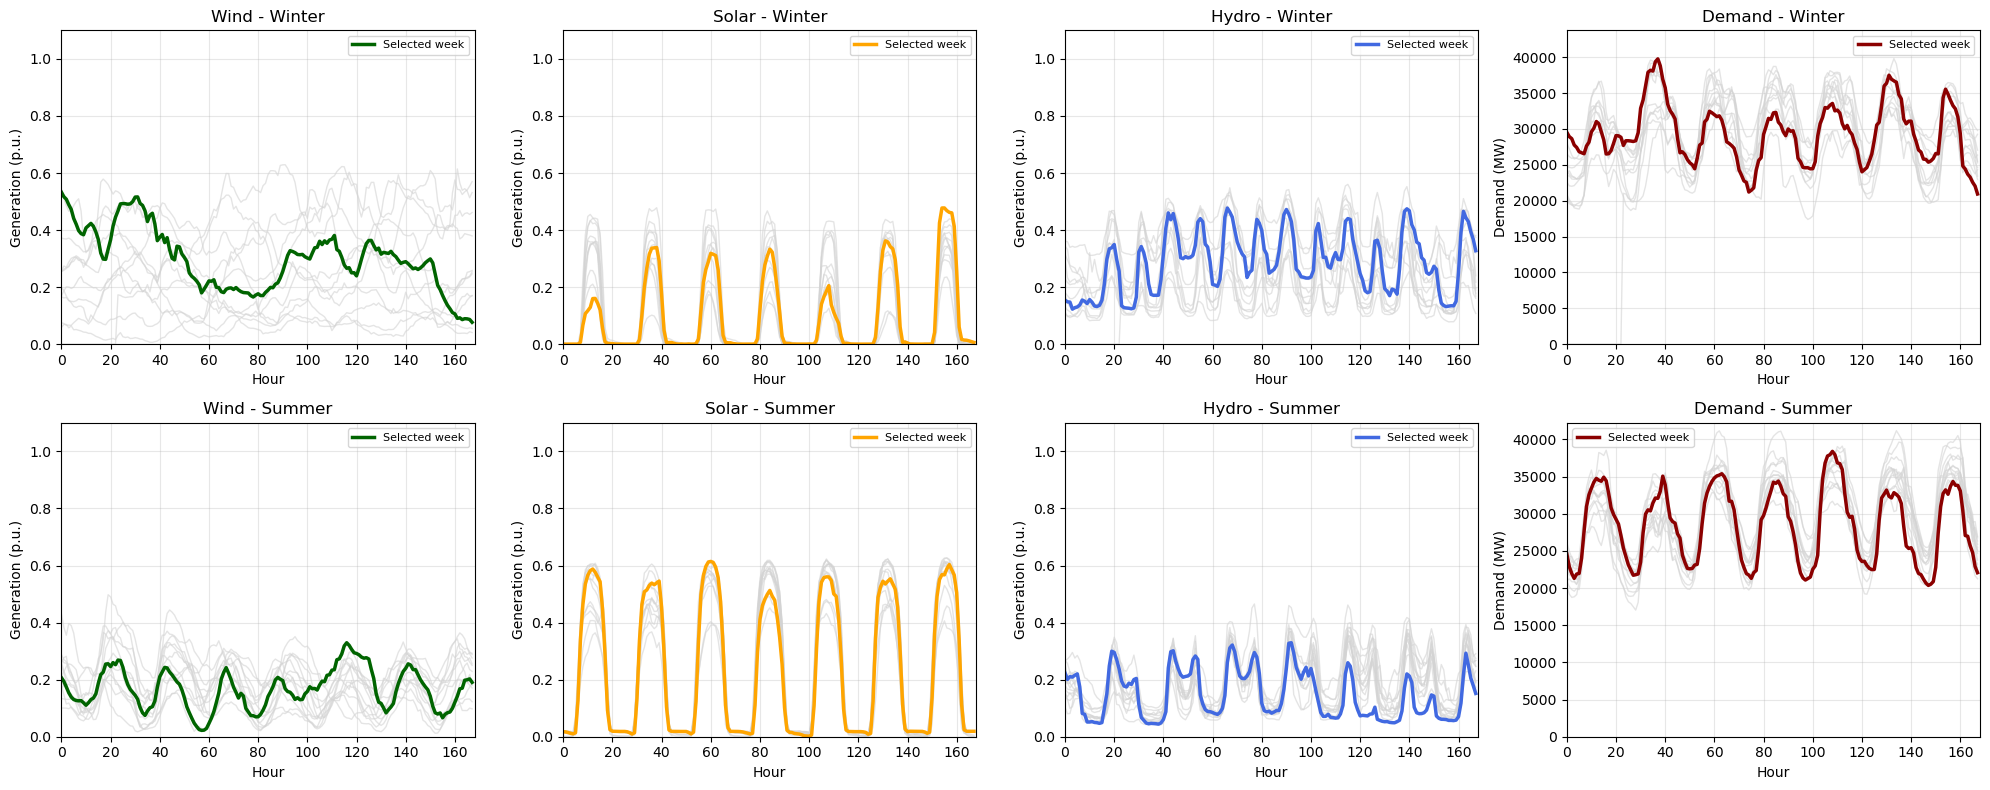

In [8]:
# --- Calculate p.u. generation for Wind, Solar, and Hydro + Demand ---
season_months = {
    'Winter': [12, 1, 2],
    'Summer': [6, 7, 8]
}

# Get capacities for p.u. calculation
wind_cap = tech_caps.get('Wind', 1.0)
solar_cap = tech_caps.get('Solar', 1.0)
hydro_cap = tech_caps.get('Hydro', 1.0)

print(f"Wind capacity: {wind_cap:.2f} MW")
print(f"Solar capacity: {solar_cap:.2f} MW")
print(f"Hydro capacity: {hydro_cap:.2f} MW\n")

# Store all weekly data and random selection per season
all_weekly_data = {}
pu_gen = {}

for season, months in season_months.items():
    # Subset data for season
    gb = gen_by_tech.copy()
    season_data = gb[gb.index.month.isin(months)]
    
    # Extract 7-day windows
    weekly = []
    start = season_data.index[0].floor('D')
    end = season_data.index[-1].ceil('D')
    current = start
    while current + pd.Timedelta(days=7) <= end:
        week_slice = season_data.loc[current:current + pd.Timedelta(days=7) - pd.Timedelta(hours=1)]
        if len(week_slice) == 168:
            weekly.append(week_slice)
        current += pd.Timedelta(days=7)
    
    print(f"{season}: found {len(weekly)} full weeks")
    
    # Store all weeks' p.u. data and demand
    all_weekly_data[season] = {'Wind': [], 'Solar': [], 'Hydro': [], 'Demand': []}
    for week_data in weekly:
        all_weekly_data[season]['Wind'].append(week_data.get('Wind', pd.Series(0, index=week_data.index)).values / wind_cap)
        all_weekly_data[season]['Solar'].append(week_data.get('Solar', pd.Series(0, index=week_data.index)).values / solar_cap)
        all_weekly_data[season]['Hydro'].append(week_data.get('Hydro', pd.Series(0, index=week_data.index)).values / hydro_cap)
        all_weekly_data[season]['Demand'].append(week_data.get('demand', pd.Series(0, index=week_data.index)).values)
    
    # Select random week
    if weekly:
        random_idx = np.random.randint(0, len(weekly))
        random_week = weekly[random_idx]
        
        # Store random week data
        pu_gen[season] = pd.DataFrame(index=random_week.index)
        pu_gen[season]['Wind'] = random_week.get('Wind', pd.Series(0, index=random_week.index)) / wind_cap
        pu_gen[season]['Solar'] = random_week.get('Solar', pd.Series(0, index=random_week.index)) / solar_cap
        pu_gen[season]['Hydro'] = random_week.get('Hydro', pd.Series(0, index=random_week.index)) / hydro_cap
        pu_gen[season]['Demand'] = random_week.get('demand', pd.Series(0, index=random_week.index))
        
        print(f"{season} week range: {random_week.index[0]} to {random_week.index[-1]}\n")

# Plot p.u. generation and demand for random weeks with all weeks in background
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

colors = {'Wind': 'darkgreen', 'Solar': 'orange', 'Hydro': 'royalblue', 'Demand': 'darkred'}

# Calculate common x-axis limits
x_max = max(len(data) for data in pu_gen.values())

for row, (season, data) in enumerate(pu_gen.items()):
    for col, tech in enumerate(['Wind', 'Solar', 'Hydro', 'Demand']):
        ax = axes[row, col]
        
        # Plot all weeks in light grey
        for week_profile in all_weekly_data[season][tech]:
            ax.plot(range(len(week_profile)), week_profile, 
                    color='lightgrey', linewidth=1.0, alpha=0.6)
        
        # Overlay random week in bold color
        ax.plot(range(len(data)), data[tech].values, 
                color=colors[tech], linewidth=2.5, label='Selected week')
        
        ax.set_title(f"{tech} - {season}")
        if tech == 'Demand':
            ax.set_ylabel('Demand (MW)')
            ax.set_ylim([0, max(data[tech].values) * 1.1])
        else:
            ax.set_ylabel('Generation (p.u.)')
            ax.set_ylim([0, 1.1])
        ax.set_xlabel('Hour')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, x_max])
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

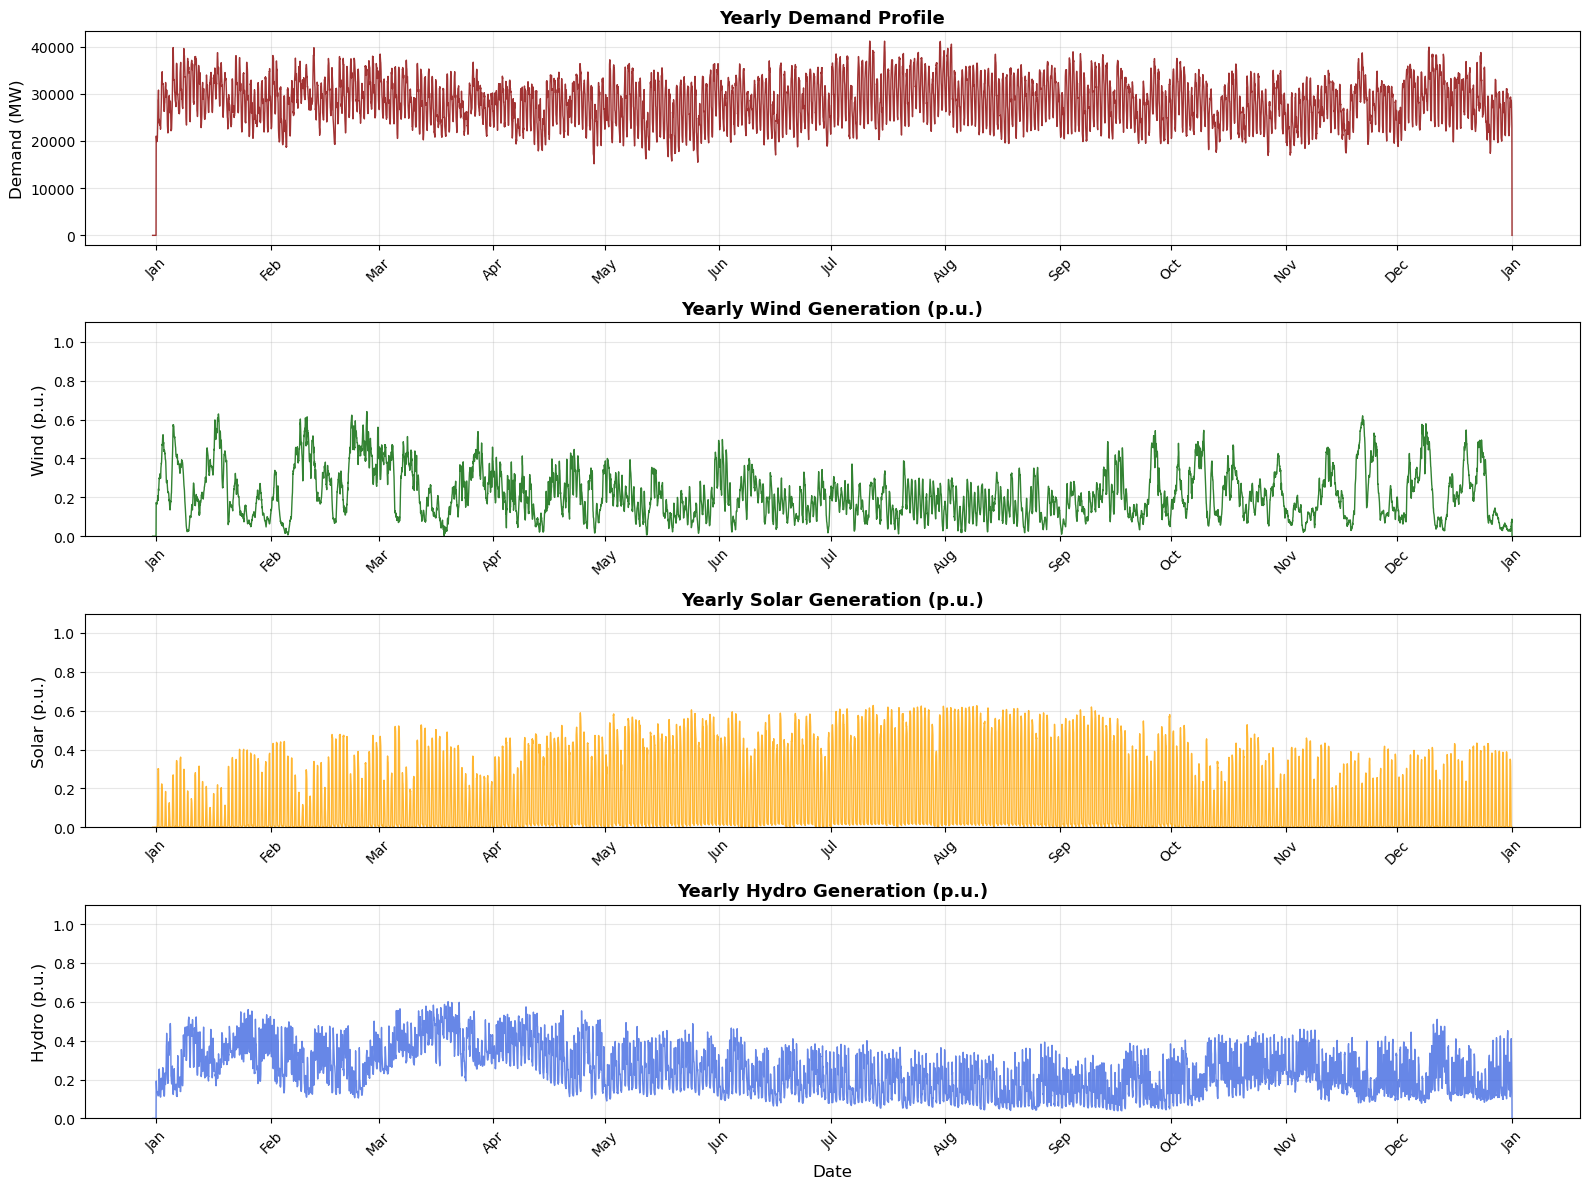

Demand (MW):
  Average: 28246.14
  Peak: 41177.93
  Min: 0.00

Wind Generation (p.u.):
  Average: 0.216
  Peak: 0.641
  Min: 0.000

Solar Generation (p.u.):
  Average: 0.161
  Peak: 0.627
  Min: 0.000

Hydro Generation (p.u.):
  Average: 0.240
  Peak: 0.601
  Min: 0.000


In [9]:
# Plot yearly Demand + Solar, Wind, and Hydro in p.u.
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Calculate p.u. values for each technology
wind_pu = gen_by_tech['Wind'] / wind_cap
solar_pu = gen_by_tech['Solar'] / solar_cap
hydro_pu = gen_by_tech['Hydro'] / hydro_cap
yearly_demand = gen_by_tech['demand']

# Plot Demand
axes[0].plot(yearly_demand.index, yearly_demand.values, color='darkred', linewidth=1, alpha=0.8)
axes[0].set_ylabel('Demand (MW)', fontsize=12)
axes[0].set_title('Yearly Demand Profile', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot Wind
axes[1].plot(wind_pu.index, wind_pu.values, color='darkgreen', linewidth=1, alpha=0.8)
axes[1].set_ylabel('Wind (p.u.)', fontsize=12)
axes[1].set_title('Yearly Wind Generation (p.u.)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.1])

# Plot Solar
axes[2].plot(solar_pu.index, solar_pu.values, color='orange', linewidth=1, alpha=0.8)
axes[2].set_ylabel('Solar (p.u.)', fontsize=12)
axes[2].set_title('Yearly Solar Generation (p.u.)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 1.1])

# Plot Hydro
axes[3].plot(hydro_pu.index, hydro_pu.values, color='royalblue', linewidth=1, alpha=0.8)
axes[3].set_ylabel('Hydro (p.u.)', fontsize=12)
axes[3].set_xlabel('Date', fontsize=12)
axes[3].set_title('Yearly Hydro Generation (p.u.)', fontsize=13, fontweight='bold')
axes[3].grid(True, alpha=0.3)
axes[3].set_ylim([0, 1.1])

# Format x-axis to show months for all subplots
import matplotlib.dates as mdates
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# Print statistics
print("Demand (MW):")
print(f"  Average: {yearly_demand.mean():.2f}")
print(f"  Peak: {yearly_demand.max():.2f}")
print(f"  Min: {yearly_demand.min():.2f}\n")

print("Wind Generation (p.u.):")
print(f"  Average: {wind_pu.mean():.3f}")
print(f"  Peak: {wind_pu.max():.3f}")
print(f"  Min: {wind_pu.min():.3f}\n")

print("Solar Generation (p.u.):")
print(f"  Average: {solar_pu.mean():.3f}")
print(f"  Peak: {solar_pu.max():.3f}")
print(f"  Min: {solar_pu.min():.3f}\n")

print("Hydro Generation (p.u.):")
print(f"  Average: {hydro_pu.mean():.3f}")
print(f"  Peak: {hydro_pu.max():.3f}")
print(f"  Min: {hydro_pu.min():.3f}")

In [10]:
# =====================
# 5) Geographic Flow Map (Folium with Capacities)
# =====================
print("\n" + "="*70)
print("GEOGRAPHIC POWER FLOW MAP")
print("="*70)

try:
    import folium
    from folium import plugins
    from IPython.display import HTML
    
    # Bus coordinates (latitude, longitude)
    bus_coords = {
        "ES": (40.4637, -3.7492),      # Madrid area
        "FR": (48.8566, 2.3522),      # Paris area
        "IT": (41.9028, 12.4964),      # Rome area
        "PT": (38.7223, -9.1393)    # Lisbon area
    }
    
    # Network connections: (source, target, NTC_MW)
    power_flows = [
        ("ES", "FR", 3500),
        ("FR", "IT", 4500),
        ("ES", "IT", 2000),
        ("ES", "PT", 4500)
    ]
    
    # Create base map centered on Europe
    center_lat = sum(coord[0] for coord in bus_coords.values()) / len(bus_coords)
    center_lon = sum(coord[1] for coord in bus_coords.values()) / len(bus_coords)
    
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=5,
        tiles='OpenStreetMap',
        prefer_canvas=True
    )
    
    # Plot network connections with simple dash separators
    for source, target, flow_mw in power_flows:
        lat0, lon0 = bus_coords[source]
        lat1, lon1 = bus_coords[target]
        
        # Draw connection line (simple black line)
        folium.PolyLine(
            locations=[[lat0, lon0], [lat1, lon1]],
            color='black',
            weight=2,
            opacity=0.8,
            popup=f"<b>{source} - {target}</b><br>NTC: {flow_mw} MW",
            tooltip=f"{source} - {target}"
        ).add_to(m)
        
        # Add dash separator at midpoint
        mid_lat = (lat0 + lat1) / 2
        mid_lon = (lon0 + lon1) / 2
        
        label_html = f'''
        <div style="font-size: 16px; font-weight: bold; color: black; 
                    text-shadow: -1px -1px 1px white, 1px -1px 1px white, -1px 1px 1px white, 1px 1px 1px white;
                    background-color: rgba(255,255,255,0.75); padding: 4px 6px; border-radius: 3px; white-space: nowrap;">
        {source} - {target} {flow_mw} MW
        </div>
        '''
        
        folium.Marker(
            location=[mid_lat, mid_lon],
            icon=folium.DivIcon(html=label_html),
            popup=f"<b>{source} - {target}</b><br>NTC: {flow_mw} MW"
        ).add_to(m)
    
    # Plot substations (nodes) with larger markers
    for bus_name in bus_coords.keys():
        lat, lon = bus_coords[bus_name]
        
        folium.CircleMarker(
            location=[lat, lon],
            radius=25,
            popup=f"<b>{bus_name}</b><br>400 kV Substation",
            tooltip=bus_name,
            color='#c92a2a',
            fill=True,
            fillColor='#ff6b6b',
            fillOpacity=0.95,
            weight=4,
            zindex=100
        ).add_to(m)
        
        # Add country label
        folium.Marker(
            location=[lat, lon],
            icon=folium.DivIcon(html=f'''
            <div style="font-size: 12px; font-weight: bold; color: white;">
            {bus_name}
            </div>
            '''),
            popup=f"{bus_name} - 400 kV AC"
        ).add_to(m)
    
    # Add title with legend
    title_html = '''
    <div style="position: fixed; 
                top: 10px; left: 50px; width: 360px; height: auto;
                background-color: white; border:2px solid #333; z-index:9999; 
                font-size: 12px; padding: 10px; border-radius: 5px;
                box-shadow: 0 0 10px rgba(0,0,0,0.2);">
    <b style="font-size: 13px;">Network Capacity: 400 kV AC</b><br>
    <span style="font-size: 10px; color: #666;">Lines show NTC capacity</span><br>
    <div style="font-size: 10px; margin-top: 6px; line-height: 1.4;">
    </div>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(title_html))
    
    # Display the map
    print("ÃƒÂ¢Ã…â€œÃ¢€Å“ Geographic capacity map created successfully!")
    display(HTML(m._repr_html_()))
    
except ImportError:
    print("Folium not installed. Installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'folium', '-q'])
    print("Folium installed. Please rerun this cell.")
    
except Exception as e:
    print(f"Error: {type(e).__name__}: {str(e)}")
    print("Could not create geographic capacity map.")


GEOGRAPHIC POWER FLOW MAP
ÃƒÂ¢Ã…â€œÃ¢€Å“ Geographic capacity map created successfully!


In [11]:
# --- Load generation data for each country ---
import pandas as pd
import numpy as np
from pathlib import Path

countries_data_path = Path('./Data/Countries interconnected Data')

# Dictionary to store generation by tech for each country
gen_by_tech_countries = {}

# Country mapping
country_files = {
    'France': 'France_AGGREGATED_GENERATION_PER_TYPE_GENERATION.csv',
    'Italy': 'Italy_AGGREGATED_GENERATION_PER_TYPE_GENERATION.csv',
    'Portugal': 'Portugal_AGGREGATED_GENERATION_PER_TYPE_GENERATION.csv',
}

for country, filename in country_files.items():
    filepath = countries_data_path / filename
    
    # Read the CSV
    df = pd.read_csv(filepath, sep=';')
    
    # Strip whitespace from column names
    df.columns = df.columns.str.strip()
    
    # Parse timestamp column to extract datetime
    # Format: "01/01/2024 00:00:00 - 01/01/2024 01:00:00" (may have timezone like " (CET)")
    # Extract start time and remove any trailing timezone info
    timestep_start = df['Timestep'].str.split(' - ', n=1, expand=True, regex=False)[0]
    timestep_clean = timestep_start.str.split(' (', n=1, expand=True, regex=False)[0]
    df['datetime'] = pd.to_datetime(timestep_clean, format='%d/%m/%Y %H:%M:%S')
    
    # Function to clean values (convert 'n/e' and other non-numeric to 0)
    def clean_value(val):
        if pd.isna(val):
            return 0.0
        s = str(val).strip().lower()
        if s in ['n/e', 'n/a', '']:
            return 0.0
        try:
            return float(val)
        except:
            return 0.0
    
    # Extract and aggregate wind (Onshore + Offshore)
    wind_onshore = df.loc[:, 'Wind Onshore (MW)'].apply(clean_value).values
    wind_offshore = df.loc[:, 'Wind Offshore (MW)'].apply(clean_value).values
    wind = wind_onshore + wind_offshore
    
    # Extract solar
    solar = df.loc[:, 'Solar (MW)'].apply(clean_value).values
    
    # Extract hydro (Reservoir + Run-of-river & pondage)
    # Note: Excluding pumped storage as it's not main generation
    hydro_reservoir = df.loc[:, 'Hydro Water Reservoir (MW)'].apply(clean_value).values
    hydro_runofriver = df.loc[:, 'Hydro Run-of-river and pondage (MW)'].apply(clean_value).values
    hydro = hydro_reservoir + hydro_runofriver
    
    # Extract nuclear and fossil fuel generation
    nuclear = df.loc[:, 'Nuclear (MW)'].apply(clean_value).values
    coal = df.loc[:, 'Fossil Hard coal (MW)'].apply(clean_value).values
    fossil_gas = df.loc[:, 'Fossil Gas (MW)'].apply(clean_value).values
    
    # Create generation by tech dataframe (before setting index to handle duplicates)
    gen_df = pd.DataFrame({
        'datetime': df['datetime'],
        'Wind': wind,
        'Solar': solar,
        'Hydro': hydro,
        'Nuclear': nuclear,
        'Coal': coal,
        'Fossil Gas': fossil_gas,
    })
    
    # Handle duplicate timestamps by taking the mean (in case of DST transitions)
    gen_by_tech = gen_df.groupby('datetime').mean()
    gen_by_tech.index.name = 'datetime'
    
    # Ensure hourly frequency (reindex to fill any gaps)
    full_index = pd.date_range(
        start=gen_by_tech.index.min().floor('D'),
        end=gen_by_tech.index.max().ceil('D') - pd.Timedelta(hours=1),
        freq='h'
    )
    gen_by_tech = gen_by_tech.reindex(full_index).fillna(0.0)
    gen_by_tech.index.name = 'datetime'
    
    # Add demand as sum of all generation
    gen_by_tech['demand'] = gen_by_tech[['Wind', 'Solar', 'Hydro', 'Nuclear', 'Coal', 'Fossil Gas']].sum(axis=1)
    
    gen_by_tech_countries[country] = gen_by_tech
    
    print(f"\n{country}:")
    print(f"  Shape: {gen_by_tech.shape}")
    print(f"  Date range: {gen_by_tech.index.min()} to {gen_by_tech.index.max()}")
    print(f"  Average demand: {gen_by_tech['demand'].mean():.1f} MW")
    display(gen_by_tech.head())


France:
  Shape: (8784, 7)
  Date range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
  Average demand: 58104.5 MW


,Wind,Solar,Hydro,Nuclear,Coal,Fossil Gas,demand
datetime,,,,,,,
2024-01-01 00:00:00,14977.0,225.0,6303.0,40387.0,15.0,1810.0,63717.0
2024-01-01 01:00:00,14734.0,0.0,6049.0,37528.0,16.0,1840.0,60167.0
2024-01-01 02:00:00,14367.0,0.0,5923.0,37320.0,16.0,1787.0,59413.0
2024-01-01 03:00:00,13393.0,0.0,5812.0,36954.0,15.0,1778.0,57952.0
2024-01-01 04:00:00,8607.0,0.0,5661.0,36906.0,15.0,1765.0,52954.0



Italy:
  Shape: (8784, 7)
  Date range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
  Average demand: 21994.3 MW


,Wind,Solar,Hydro,Nuclear,Coal,Fossil Gas,demand
datetime,,,,,,,
2024-01-01 00:00:00,3905.0,0.0,2358.0,0.0,423.0,8652.0,15338.0
2024-01-01 01:00:00,3927.0,0.0,2195.0,0.0,424.0,7679.0,14225.0
2024-01-01 02:00:00,4041.0,0.0,2051.0,0.0,424.0,6774.0,13290.0
2024-01-01 03:00:00,4122.0,0.0,2008.0,0.0,424.0,6516.0,13070.0
2024-01-01 04:00:00,4018.0,0.0,1912.0,0.0,424.0,6308.0,12662.0



Portugal:
  Shape: (8784, 7)
  Date range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
  Average demand: 4095.9 MW


,Wind,Solar,Hydro,Nuclear,Coal,Fossil Gas,demand
datetime,,,,,,,
2024-01-01 00:00:00,351.9,0.1,902.2,0.0,0.0,190.9,1445.1
2024-01-01 01:00:00,342.7,0.0,776.0,0.0,0.0,192.7,1311.4
2024-01-01 02:00:00,413.9,0.0,643.4,0.0,0.0,190.1,1247.4
2024-01-01 03:00:00,487.1,0.0,1239.3,0.0,0.0,189.7,1916.1
2024-01-01 04:00:00,510.7,0.0,930.5,0.0,0.0,189.9,1631.1



MULTI-COUNTRY P.U. GENERATION ANALYSIS - FULL YEAR


Processing: Spain (p.u. data already available)

Data range: 2023-12-31 00:00:00+00:00 to 2024-12-31 23:00:00+00:00
Total hours: 8808 hours

Demand Statistics:
  Average: 28,246 MW
  Peak: 41,178 MW
  Minimum: 0 MW

Renewable Capacity Factors (mean p.u.):
  Wind: 0.216 (21.6%)
  Solar: 0.161 (16.1%)
  Hydro: 0.240 (24.0%)


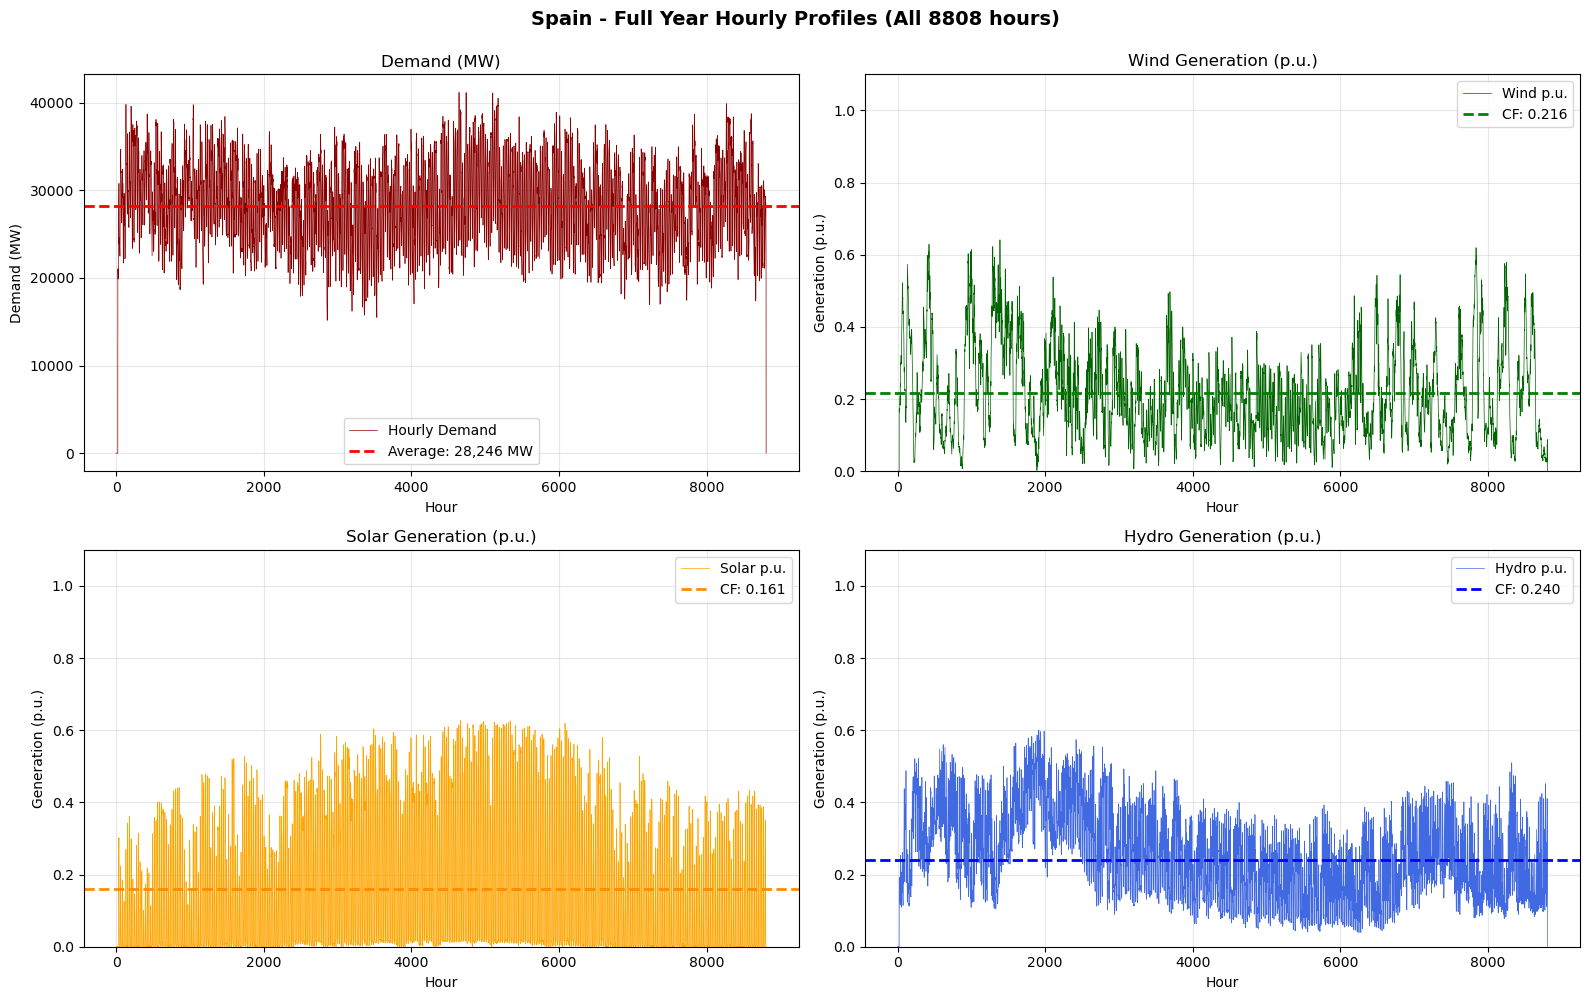


ÃƒÂ¢Ã…â€œÃ¢€Å“ Spain full-year plots completed

Installed capacities for other countries (MW):
  France: Wind=24,500, Solar=20,000, Hydro=25,500
  Italy: Wind=13,600, Solar=37,500, Hydro=22,089
  Portugal: Wind=6,000, Solar=3,500, Hydro=7,200


Processing: France

Installed capacity (p.u. basis):
  Wind: 24,500 MW
  Solar: 20,000 MW
  Hydro: 25,500 MW

Data range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
Total hours: 8784 hours

Demand Statistics:
  Average: 58,105 MW
  Peak: 81,066 MW
  Minimum: 0 MW

Renewable Capacity Factors (mean p.u.):
  Wind: 0.213 (21.3%)
  Solar: 0.133 (13.3%)
  Hydro: 0.283 (28.3%)


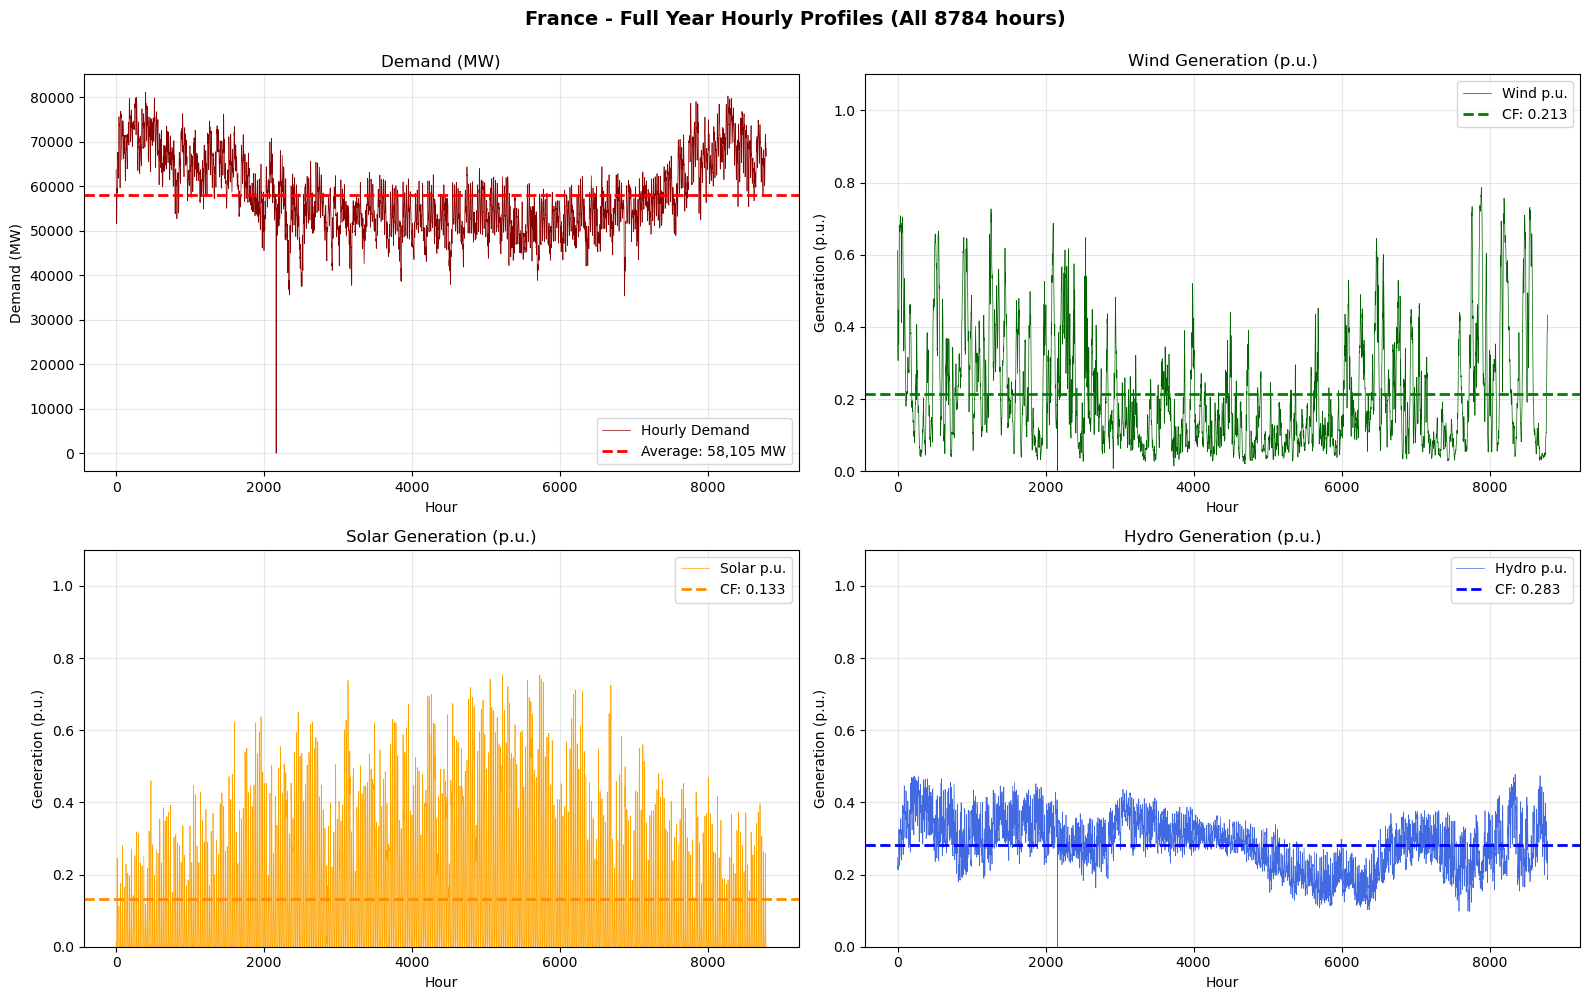


ÃƒÂ¢Ã…â€œÃ¢€Å“ France full-year plots completed


Processing: Italy

Installed capacity (p.u. basis):
  Wind: 13,600 MW
  Solar: 37,500 MW
  Hydro: 22,089 MW

Data range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
Total hours: 8784 hours

Demand Statistics:
  Average: 21,994 MW
  Peak: 41,529 MW
  Minimum: 0 MW

Renewable Capacity Factors (mean p.u.):
  Wind: 0.184 (18.4%)
  Solar: 0.084 (8.4%)
  Hydro: 0.238 (23.8%)


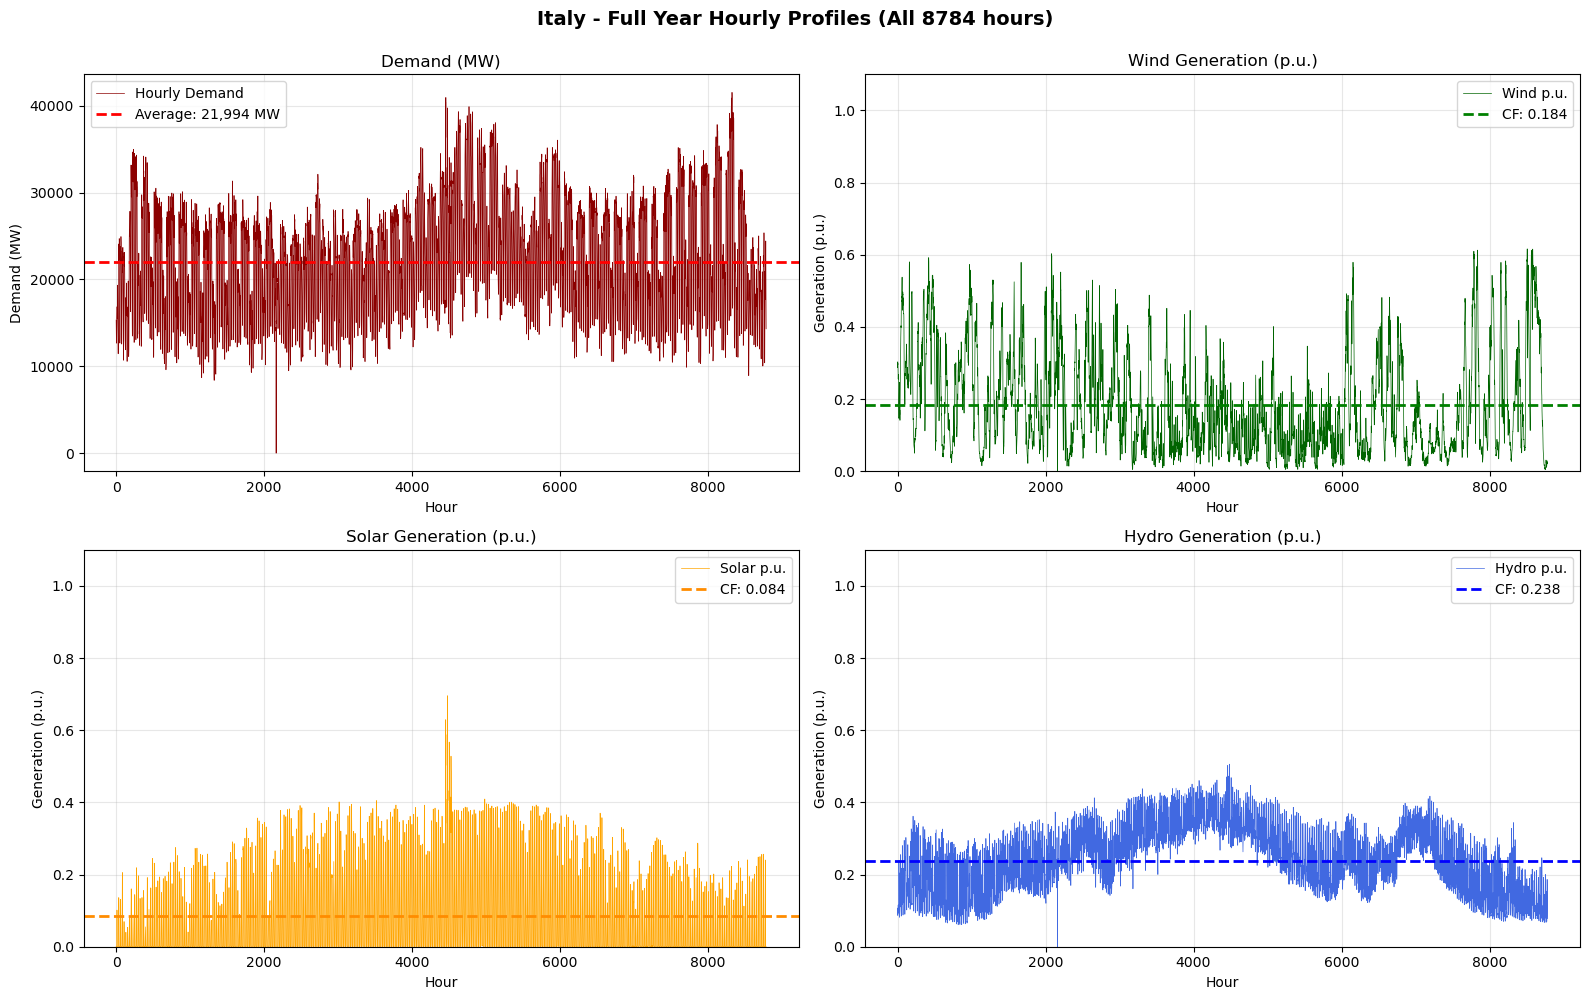


ÃƒÂ¢Ã…â€œÃ¢€Å“ Italy full-year plots completed


Processing: Portugal

Installed capacity (p.u. basis):
  Wind: 6,000 MW
  Solar: 3,500 MW
  Hydro: 7,200 MW

Data range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
Total hours: 8784 hours

Demand Statistics:
  Average: 4,096 MW
  Peak: 9,674 MW
  Minimum: 0 MW

Renewable Capacity Factors (mean p.u.):
  Wind: 0.268 (26.8%)
  Solar: 0.160 (16.0%)
  Hydro: 0.190 (19.0%)


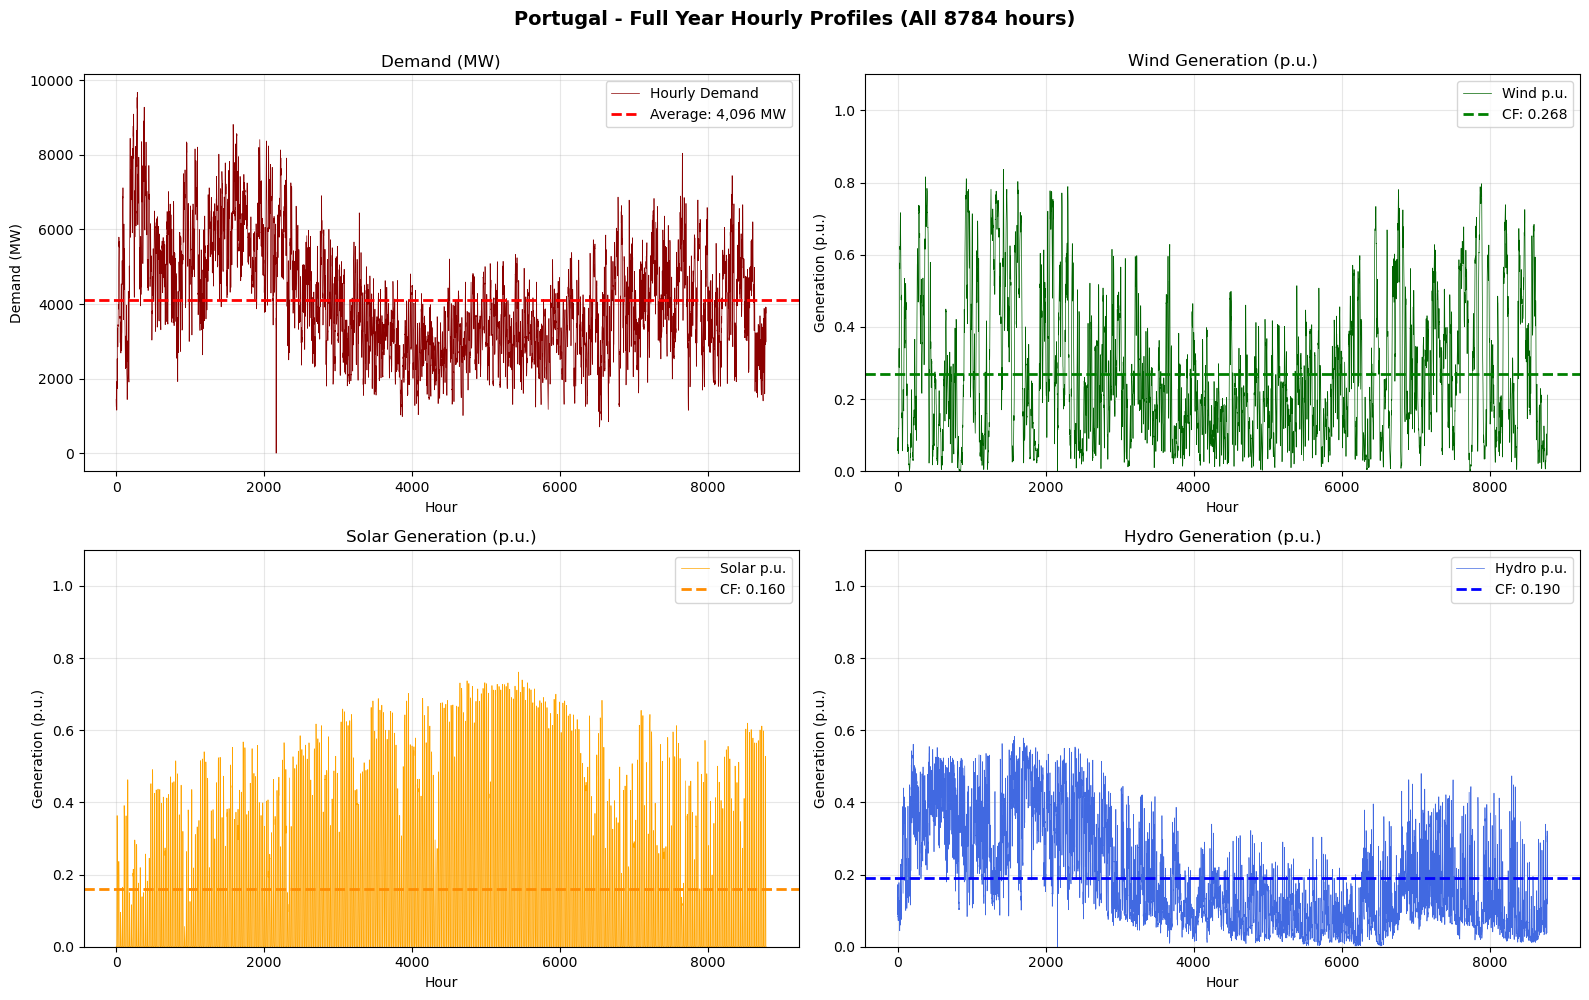


ÃƒÂ¢Ã…â€œÃ¢€Å“ Portugal full-year plots completed

Multi-country analysis complete!

AGGREGATED MULTI-COUNTRY DATA SUMMARY (FULL YEAR)

ÃƒÂ¢Ã…â€œÃ¢€Å“ all_countries_hourly_demand - Dictionary containing hourly demand for each country:
  Spain: 8808 hourly values (MW)
  France: 8784 hourly values (MW)
  Italy: 8784 hourly values (MW)
  Portugal: 8784 hourly values (MW)

ÃƒÂ¢Ã…â€œÃ¢€Å“ all_countries_pu_renewables - Dictionary containing p.u. renewables for each country:
  Spain:
    Wind: 8808 hourly values (p.u.)
    Solar: 8808 hourly values (p.u.)
    Hydro: 8808 hourly values (p.u.)
  France:
    Wind: 8784 hourly values (p.u.)
    Solar: 8784 hourly values (p.u.)
    Hydro: 8784 hourly values (p.u.)
  Italy:
    Wind: 8784 hourly values (p.u.)
    Solar: 8784 hourly values (p.u.)
    Hydro: 8784 hourly values (p.u.)
  Portugal:
    Wind: 8784 hourly values (p.u.)
    Solar: 8784 hourly values (p.u.)
    Hydro: 8784 hourly values (p.u.)

Total hours per country: 8808
Equivalent to: 

In [12]:
# --- Plot p.u. generation for all countries (FULL YEAR) ---
import matplotlib.pyplot as plt
print("\n" + "="*70)
print("MULTI-COUNTRY P.U. GENERATION ANALYSIS - FULL YEAR")
print("="*70 + "\n")

# Initialize aggregated variables
all_countries_hourly_demand = {}
all_countries_pu_renewables = {}

# ===== SPAIN (already in p.u.) =====
print(f"\n{'='*70}")
print("Processing: Spain (p.u. data already available)")
print(f"{'='*70}")
print(f"\nData range: {wind_pu.index[0]} to {wind_pu.index[-1]}")
print(f"Total hours: {len(wind_pu)} hours\n")

# Store Spain's already-calculated p.u. series
spain_wind_pu = wind_pu.values if hasattr(wind_pu, 'values') else wind_pu
spain_solar_pu = solar_pu.values if hasattr(solar_pu, 'values') else solar_pu
spain_hydro_pu = hydro_pu.values if hasattr(hydro_pu, 'values') else hydro_pu
spain_demand = yearly_demand.values if hasattr(yearly_demand, 'values') else yearly_demand

# Calculate capacity factors for Spain
spain_wind_cf = np.mean(spain_wind_pu)
spain_solar_cf = np.mean(spain_solar_pu)
spain_hydro_cf = np.mean(spain_hydro_pu)
spain_avg_demand = np.mean(spain_demand)
spain_peak_demand = np.max(spain_demand)
spain_min_demand = np.min(spain_demand)

print(f"Demand Statistics:")
print(f"  Average: {spain_avg_demand:,.0f} MW")
print(f"  Peak: {spain_peak_demand:,.0f} MW")
print(f"  Minimum: {spain_min_demand:,.0f} MW")
print(f"\nRenewable Capacity Factors (mean p.u.):")
print(f"  Wind: {spain_wind_cf:.3f} ({spain_wind_cf*100:.1f}%)")
print(f"  Solar: {spain_solar_cf:.3f} ({spain_solar_cf*100:.1f}%)")
print(f"  Hydro: {spain_hydro_cf:.3f} ({spain_hydro_cf*100:.1f}%)")

# Store Spain data
all_countries_hourly_demand['Spain'] = spain_demand
all_countries_pu_renewables['Spain'] = {
    'Wind': spain_wind_pu,
    'Solar': spain_solar_pu,
    'Hydro': spain_hydro_pu
}

# Plot Spain
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'Spain - Full Year Hourly Profiles (All {len(spain_wind_pu)} hours)', 
             fontsize=14, fontweight='bold', y=0.995)

ax = axes[0, 0]
ax.plot(range(len(spain_demand)), spain_demand, color='darkred', linewidth=0.5, label='Hourly Demand')
ax.axhline(spain_avg_demand, color='red', linestyle='--', linewidth=2, label=f'Average: {spain_avg_demand:,.0f} MW')
ax.set_title('Demand (MW)')
ax.set_ylabel('Demand (MW)')
ax.set_xlabel('Hour')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[0, 1]
ax.plot(range(len(spain_wind_pu)), spain_wind_pu, color='darkgreen', linewidth=0.5, label='Wind p.u.')
ax.axhline(spain_wind_cf, color='green', linestyle='--', linewidth=2, label=f'CF: {spain_wind_cf:.3f}')
ax.set_title('Wind Generation (p.u.)')
ax.set_ylabel('Generation (p.u.)')
ax.set_ylim([0, 1.1])
ax.set_xlabel('Hour')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 0]
ax.plot(range(len(spain_solar_pu)), spain_solar_pu, color='orange', linewidth=0.5, label='Solar p.u.')
ax.axhline(spain_solar_cf, color='darkorange', linestyle='--', linewidth=2, label=f'CF: {spain_solar_cf:.3f}')
ax.set_title('Solar Generation (p.u.)')
ax.set_ylabel('Generation (p.u.)')
ax.set_ylim([0, 1.1])
ax.set_xlabel('Hour')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 1]
ax.plot(range(len(spain_hydro_pu)), spain_hydro_pu, color='royalblue', linewidth=0.5, label='Hydro p.u.')
ax.axhline(spain_hydro_cf, color='blue', linestyle='--', linewidth=2, label=f'CF: {spain_hydro_cf:.3f}')
ax.set_title('Hydro Generation (p.u.)')
ax.set_ylabel('Generation (p.u.)')
ax.set_ylim([0, 1.1])
ax.set_xlabel('Hour')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
print(f"\nÃƒÂ¢Ã…â€œÃ¢€Å“ Spain full-year plots completed\n")

# ===== OTHER COUNTRIES (calculate p.u. from installed capacity) =====
# Define installed capacities for other countries (GW converted to MW)
wind_cap_country = {
    "France": 24500,
    "Italy": 13600,
    "Portugal": 6000
}

solar_cap_country = {
    "France": 20000,
    "Italy": 37500,
    "Portugal": 3500
}

hydro_cap_country = {
    "France": 25500,
    "Italy": 22089,
    "Portugal": 7200
}

print("Installed capacities for other countries (MW):")
for country in wind_cap_country.keys():
    print(f"  {country}: Wind={wind_cap_country[country]:,}, Solar={solar_cap_country[country]:,}, Hydro={hydro_cap_country[country]:,}")
print()

# Loop through other countries
for country_name, gen_by_tech_country in gen_by_tech_countries.items():
    print(f"\n{'='*70}")
    print(f"Processing: {country_name}")
    print(f"{'='*70}")
    
    wind_cap = wind_cap_country.get(country_name, 1000.0)
    solar_cap = solar_cap_country.get(country_name, 1000.0)
    hydro_cap = hydro_cap_country.get(country_name, 1000.0)
    
    print(f"\nInstalled capacity (p.u. basis):")
    print(f"  Wind: {wind_cap:,.0f} MW")
    print(f"  Solar: {solar_cap:,.0f} MW")
    print(f"  Hydro: {hydro_cap:,.0f} MW")
    print(f"\nData range: {gen_by_tech_country.index[0]} to {gen_by_tech_country.index[-1]}")
    print(f"Total hours: {len(gen_by_tech_country)} hours\n")
    
    # Calculate p.u. for this country
    demand_arr = gen_by_tech_country['demand'].values
    wind_pu_arr = gen_by_tech_country['Wind'].values / wind_cap if wind_cap > 0 else np.zeros(len(gen_by_tech_country))
    solar_pu_arr = gen_by_tech_country['Solar'].values / solar_cap if solar_cap > 0 else np.zeros(len(gen_by_tech_country))
    hydro_pu_arr = gen_by_tech_country['Hydro'].values / hydro_cap if hydro_cap > 0 else np.zeros(len(gen_by_tech_country))
    
    # Calculate statistics
    avg_demand = np.mean(demand_arr)
    peak_demand = np.max(demand_arr)
    min_demand = np.min(demand_arr)
    wind_cf = np.mean(wind_pu_arr)
    solar_cf = np.mean(solar_pu_arr)
    hydro_cf = np.mean(hydro_pu_arr)
    
    print(f"Demand Statistics:")
    print(f"  Average: {avg_demand:,.0f} MW")
    print(f"  Peak: {peak_demand:,.0f} MW")
    print(f"  Minimum: {min_demand:,.0f} MW")
    print(f"\nRenewable Capacity Factors (mean p.u.):")
    print(f"  Wind: {wind_cf:.3f} ({wind_cf*100:.1f}%)")
    print(f"  Solar: {solar_cf:.3f} ({solar_cf*100:.1f}%)")
    print(f"  Hydro: {hydro_cf:.3f} ({hydro_cf*100:.1f}%)")
    
    # Store data
    all_countries_hourly_demand[country_name] = demand_arr
    all_countries_pu_renewables[country_name] = {
        'Wind': wind_pu_arr,
        'Solar': solar_pu_arr,
        'Hydro': hydro_pu_arr
    }
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{country_name} - Full Year Hourly Profiles (All {len(gen_by_tech_country)} hours)', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    ax = axes[0, 0]
    ax.plot(range(len(demand_arr)), demand_arr, color='darkred', linewidth=0.5, label='Hourly Demand')
    ax.axhline(avg_demand, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_demand:,.0f} MW')
    ax.set_title('Demand (MW)')
    ax.set_ylabel('Demand (MW)')
    ax.set_xlabel('Hour')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    ax = axes[0, 1]
    ax.plot(range(len(wind_pu_arr)), wind_pu_arr, color='darkgreen', linewidth=0.5, label='Wind p.u.')
    ax.axhline(wind_cf, color='green', linestyle='--', linewidth=2, label=f'CF: {wind_cf:.3f}')
    ax.set_title('Wind Generation (p.u.)')
    ax.set_ylabel('Generation (p.u.)')
    ax.set_ylim([0, 1.1])
    ax.set_xlabel('Hour')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    ax = axes[1, 0]
    ax.plot(range(len(solar_pu_arr)), solar_pu_arr, color='orange', linewidth=0.5, label='Solar p.u.')
    ax.axhline(solar_cf, color='darkorange', linestyle='--', linewidth=2, label=f'CF: {solar_cf:.3f}')
    ax.set_title('Solar Generation (p.u.)')
    ax.set_ylabel('Generation (p.u.)')
    ax.set_ylim([0, 1.1])
    ax.set_xlabel('Hour')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    ax = axes[1, 1]
    ax.plot(range(len(hydro_pu_arr)), hydro_pu_arr, color='royalblue', linewidth=0.5, label='Hydro p.u.')
    ax.axhline(hydro_cf, color='blue', linestyle='--', linewidth=2, label=f'CF: {hydro_cf:.3f}')
    ax.set_title('Hydro Generation (p.u.)')
    ax.set_ylabel('Generation (p.u.)')
    ax.set_ylim([0, 1.1])
    ax.set_xlabel('Hour')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    print(f"\nÃƒÂ¢Ã…â€œÃ¢€Å“ {country_name} full-year plots completed\n")

print("="*70)
print("Multi-country analysis complete!")
print("="*70)

# Create aggregated variables summary
print("\n" + "="*70)
print("AGGREGATED MULTI-COUNTRY DATA SUMMARY (FULL YEAR)")
print("="*70 + "\n")

print("ÃƒÂ¢Ã…â€œÃ¢€Å“ all_countries_hourly_demand - Dictionary containing hourly demand for each country:")
for country in all_countries_hourly_demand:
    print(f"  {country}: {len(all_countries_hourly_demand[country])} hourly values (MW)")

print("\nÃƒÂ¢Ã…â€œÃ¢€Å“ all_countries_pu_renewables - Dictionary containing p.u. renewables for each country:")
for country in all_countries_pu_renewables:
    print(f"  {country}:")
    for tech in ['Wind', 'Solar', 'Hydro']:
        n_hours = len(all_countries_pu_renewables[country][tech])
        print(f"    {tech}: {n_hours} hourly values (p.u.)")

total_hours_per_country = len(list(all_countries_hourly_demand.values())[0]) if all_countries_hourly_demand else 0
print(f"\nTotal hours per country: {total_hours_per_country}")
print(f"Equivalent to: {total_hours_per_country/24:.1f} days ({total_hours_per_country/8760*100:.1f}% of full year)")

print("\n" + "="*70)
print("Variables are ready for further analysis!")
print("="*70)

In [13]:
# =====================
# 1. Prepare multi-country data from existing structures
# =====================

print("="*70)
print("1. PREPARING MULTI-COUNTRY OPTIMIZATION DATA")
print("="*70)

# Convert available data structures to optimization format
demands_multi = {
    'ES': all_countries_hourly_demand['Spain'] if 'Spain' in all_countries_hourly_demand else np.array([]),
    'FR': all_countries_hourly_demand['France'] if 'France' in all_countries_hourly_demand else np.array([]),
    'IT': all_countries_hourly_demand['Italy'] if 'Italy' in all_countries_hourly_demand else np.array([]),
    'PT': all_countries_hourly_demand['Portugal'] if 'Portugal' in all_countries_hourly_demand else np.array([]),
}

renewable_profiles_multi = {
    'ES': all_countries_pu_renewables['Spain'] if 'Spain' in all_countries_pu_renewables else {},
    'FR': all_countries_pu_renewables['France'] if 'France' in all_countries_pu_renewables else {},
    'IT': all_countries_pu_renewables['Italy'] if 'Italy' in all_countries_pu_renewables else {},
    'PT': all_countries_pu_renewables['Portugal'] if 'Portugal' in all_countries_pu_renewables else {},
}

print(f"\nÃƒÂ¢Ã…â€œÃ¢€Å“ Multi-country demand data prepared:")
for country_code, demand_arr in demands_multi.items():
    if len(demand_arr) > 0:
        print(f"  {country_code}: {len(demand_arr):,} hours, avg={np.mean(demand_arr):.0f} MW")
    else:
        print(f"  {country_code}: NO DATA")

print(f"\nÃƒÂ¢Ã…â€œÃ¢€Å“ Renewable profiles prepared:")
for country_code, profiles in renewable_profiles_multi.items():
    if profiles:
        print(f"  {country_code}: {len(profiles)} renewable technologies")
        for tech, data in profiles.items():
            if isinstance(data, np.ndarray):
                print(f"    - {tech}: {len(data):,} hourly values")
    else:
        print(f"  {country_code}: NO DATA")


1. PREPARING MULTI-COUNTRY OPTIMIZATION DATA

ÃƒÂ¢Ã…â€œÃ¢€Å“ Multi-country demand data prepared:
  ES: 8,808 hours, avg=28246 MW
  FR: 8,784 hours, avg=58105 MW
  IT: 8,784 hours, avg=21994 MW
  PT: 8,784 hours, avg=4096 MW

ÃƒÂ¢Ã…â€œÃ¢€Å“ Renewable profiles prepared:
  ES: 3 renewable technologies
    - Wind: 8,808 hourly values
    - Solar: 8,808 hourly values
    - Hydro: 8,808 hourly values
  FR: 3 renewable technologies
    - Wind: 8,784 hourly values
    - Solar: 8,784 hourly values
    - Hydro: 8,784 hourly values
  IT: 3 renewable technologies
    - Wind: 8,784 hourly values
    - Solar: 8,784 hourly values
    - Hydro: 8,784 hourly values
  PT: 3 renewable technologies
    - Wind: 8,784 hourly values
    - Solar: 8,784 hourly values
    - Hydro: 8,784 hourly values


# Mathematical Model: Integrated Electricity-Hydrogen-Heat Multi-Country Capacity Expansion

## 1. Overview and Network Architecture

This model extends the multi-country electricity+hydrogen capacity expansion with a coupled **heat network**. Each country has three buses: electricity (AC), hydrogen (H2), and heat, plus a gas bus that feeds the CHP.

**Key architectural rules:**
1. H2 demand satisfied only by the H2 network (electrolyzer + H2 storage + pipelines)
2. Heat demand satisfied only by **heat pumps** (electricityâ†’heat) or **CHP** (gasâ†’electricity+heat)
3. CHP simultaneously produces electricity AND heat; outputs are inseparable (back-pressure model)
4. Heat pumps consume electricity (demand side of elec balance) and produce heat (supply side of heat balance)
5. Gas bus has unlimited supply at a fixed fuel cost, feeds CHP only

---

## 2. Sets and Indices

| Symbol | Description |
|--------|-------------|
| $c \in \mathcal{C}$ | Countries: {ES, FR, IT, PT} |
| $t \in \mathcal{T}$ | Electricity technologies: {Wind, Solar, Hydro, CCGT, Coal, Nuclear} |
| $k \in \mathcal{K}$ | Heat pump types: {HP\_air\_central, HP\_air\_decentral, HP\_ground} |
| $h \in \mathcal{H}$ | Hourly time steps $h = 1, \ldots, H$ |
| $\ell \in \mathcal{L}^e$ | Electricity interconnections |
| $\ell \in \mathcal{L}^{h2}$ | H2 pipelines |
| $\delta^+(c), \delta^-(c)$ | Lines/pipes entering/leaving country $c$ |

---

## 3. Decision Variables

### 3.1 Electricity Network

| Variable | Description | Units |
|----------|-------------|-------|
| $\hat{P}_{c,t}$ | Capacity of technology $t$ **(OPTIMIZED)** | MW |
| $g_{c,t,h}$ | Hourly generation dispatch | MW |
| $\hat{P}^{\text{bat}}_c$ | Battery power capacity **(OPTIMIZED)** | MW |
| $p^{\text{bat,ch}}_{c,h}, p^{\text{bat,dis}}_{c,h}$ | Battery charge/discharge | MW |
| $e^{\text{bat}}_{c,h}$ | Battery state of charge | MWh |
| $f^e_{\ell,h}$ | Power flow on line $\ell$ | MW |

### 3.2 Hydrogen Network

| Variable | Description | Units |
|----------|-------------|-------|
| $\hat{P}^{\text{elyz}}_c, \hat{P}^{\text{fc}}_c, \hat{P}^{\text{h2s}}_c$ | Electrolyzer/Fuel cell/H2 storage capacity **(OPTIMIZED)** | MW |
| $p^{\text{elyz}}_{c,h}, p^{\text{fc}}_{c,h}$ | Electrolyzer input / Fuel cell H2 input | MW |
| $p^{\text{h2s,ch}}_{c,h}, p^{\text{h2s,dis}}_{c,h}, e^{\text{h2s}}_{c,h}$ | H2 storage charge/discharge/SoC | MW / MWh |
| $f^{h2}_{\ell,h}$ | H2 flow on pipeline $\ell$ | MWh$_\text{H2}$/h |

### 3.3 Heat Network *(NEW)*

| Variable | Description | Units |
|----------|-------------|-------|
| $\hat{P}^{\text{chp}}_c$ | CHP gas input capacity **(OPTIMIZED)** | MW$_\text{gas}$ |
| $p^{\text{chp}}_{c,h}$ | CHP gas consumption | MW$_\text{gas}$ |
| $\hat{P}^{\text{hp},k}_c$ | Heat pump $k$ elec input capacity **(OPTIMIZED)** | MW$_\text{elec}$ |
| $p^{\text{hp},k}_{c,h}$ | Heat pump $k$ electricity consumption | MW$_\text{elec}$ |

---

## 4. Parameters

| Symbol | Description | Value |
|--------|-------------|-------|
| $D^e_{c,h}$ | Electricity demand | Historical [MWh] |
| $D^{h2}_{c,h} = \alpha D^e_{c,h}$ | H2 demand | $\alpha = 0.10$ |
| $D^{\text{heat}}_{c,h} = \beta D^e_{c,h}$ | Heat demand *(NEW)* | $\beta = 0.15$ |
| $\eta^{\text{elyz}}, \eta^{\text{fc}}$ | Electrolyzer/Fuel cell efficiency | 0.65 |
| $\eta^{\text{bat,ch}}, \eta^{\text{bat,dis}}$ | Battery charge/discharge efficiency | 0.95 / 0.90 |
| $\eta^{\text{h2s,ch}}, \eta^{\text{h2s,dis}}$ | H2 storage charge/discharge efficiency | 0.65 / 0.65 |
| $\eta^{\text{chp},e}$ | CHP electrical efficiency *(NEW)* | 0.40 |
| $\eta^{\text{chp},h}$ | CHP thermal efficiency *(NEW)* | 0.40 |
| $\text{COP}_k$ | Heat pump $k$ coefficient of performance *(NEW)* | 3.0 â€“ 3.5 |
| $c^{\text{chp}}, c^{V,\text{gas}}$ | CHP capital/fuel cost *(NEW)* | EUR/MW$_\text{gas}$/yr, EUR/MWh$_\text{gas}$ |
| $c^{\text{hp},k}, c^{V,\text{hp},k}$ | HP capital/variable cost *(NEW)* | EUR/MW$_\text{elec}$/yr, EUR/MWh$_\text{elec}$ |

---

## 5. Objective Function

$$\min Z = \sum_{c,t} \left[ c^{\text{cap}}_t \hat{P}_{c,t} + \sum_h c^V_t g_{c,t,h} \right] + \sum_c c^{\text{bat}} \hat{P}^{\text{bat}}_c + \sum_c \left[ c^{\text{elyz}} \hat{P}^{\text{elyz}}_c + c^{\text{fc}} \hat{P}^{\text{fc}}_c + c^{\text{h2s}} \hat{P}^{\text{h2s}}_c \right]$$

$$+ \underbrace{\sum_c \left[ c^{\text{chp}} \hat{P}^{\text{chp}}_c + \sum_h c^{V,\text{gas}} p^{\text{chp}}_{c,h} \right]}_{\text{CHP (capex + fuel)}} + \underbrace{\sum_{c,k} \left[ c^{\text{hp},k} \hat{P}^{\text{hp},k}_c + \sum_h c^{V,\text{hp},k} p^{\text{hp},k}_{c,h} \right]}_{\text{heat pumps (capex + variable)}}$$

---

## 6. Constraints

### 6.1 Power Balance - Electricity Network *(UPDATED)*

$$\sum_{t} g_{c,t,h} + p^{\text{bat,dis}}_{c,h} + \eta^{\text{fc}} p^{\text{fc}}_{c,h} + \underbrace{\eta^{\text{chp},e} p^{\text{chp}}_{c,h}}_{\text{NEW: CHP elec}} + \sum_{\ell \in \delta^+(c)} f^e_{\ell,h}$$
$$= D^e_{c,h} + p^{\text{bat,ch}}_{c,h} + p^{\text{elyz}}_{c,h} + \underbrace{\sum_k p^{\text{hp},k}_{c,h}}_{\text{NEW: HP elec}} + \sum_{\ell \in \delta^-(c)} f^e_{\ell,h} \qquad \forall c, h$$

### 6.2 Power Balance - Hydrogen Network *(UNCHANGED)*

$$\eta^{\text{elyz}} p^{\text{elyz}}_{c,h} + p^{\text{h2s,dis}}_{c,h} + \sum_{\ell \in \delta^+(c)} f^{h2}_{\ell,h} = D^{h2}_{c,h} + p^{\text{h2s,ch}}_{c,h} + p^{\text{fc}}_{c,h} + \sum_{\ell \in \delta^-(c)} f^{h2}_{\ell,h} \qquad \forall c, h$$

### 6.3 Power Balance - Heat Network *(NEW)*

$$\underbrace{\sum_k \text{COP}_k \cdot p^{\text{hp},k}_{c,h}}_{\text{HP heat output}} + \underbrace{\eta^{\text{chp},h} \cdot p^{\text{chp}}_{c,h}}_{\text{CHP heat output}} = D^{\text{heat}}_{c,h} \qquad \forall c, h$$

> **CHP coupling:** $p^{\text{chp}}_{c,h}$ MW gas â†’ $\eta^{\text{chp},e} p^{\text{chp}}$ MW elec (supply side of elec balance) + $\eta^{\text{chp},h} p^{\text{chp}}$ MW heat (supply side of heat balance). Outputs are inseparable.

> **Heat pump:** $p^{\text{hp},k}_{c,h}$ MW elec (demand side of elec balance) â†’ $\text{COP}_k \cdot p^{\text{hp},k}$ MW heat (supply side of heat balance). COP > 1 amplifies.

### 6.4â€“6.6 Generation, Transmission, H2 Pipelines *(UNCHANGED)*

Renewables: $0 \leq g_{c,t,h} \leq CF_{c,t,h} \hat{P}_{c,t}$ ; Dispatchable: $0 \leq g_{c,t,h} \leq \hat{P}_{c,t}$

Electricity: $-NTC_\ell \leq f^e_{\ell,h} \leq NTC_\ell$ ; H2 pipes: $0 \leq f^{h2}_{\ell,h} \leq NTC^{h2}_\ell$

### 6.7 Battery Storage *(UNCHANGED)*

$0 \leq p^{\text{bat,ch}}, p^{\text{bat,dis}} \leq \hat{P}^{\text{bat}}_c$ ;
$e^{\text{bat}}_{c,h} = (1-\sigma) e^{\text{bat}}_{c,h-1} + \eta^{\text{ch}} p^{\text{ch}} - p^{\text{dis}}/\eta^{\text{dis}}$ ;
$e^{\text{bat}}_{c,h} \leq \hat{P}^{\text{bat}}_c \tau^{\text{bat}}$

### 6.8 H2 Storage *(UNCHANGED)*

$0 \leq p^{\text{h2s,ch}}, p^{\text{h2s,dis}} \leq \hat{P}^{\text{h2s}}_c$ ;
$e^{\text{h2s}}_{c,h} = (1-\sigma) e^{\text{h2s}}_{c,h-1} + \eta^{\text{ch}} p^{\text{ch}} - p^{\text{dis}}/\eta^{\text{dis}}$ ;
$e^{\text{h2s}}_{c,h} \leq \hat{P}^{\text{h2s}}_c \tau^{\text{h2s}}$

### 6.9 Electrolyzer and Fuel Cell *(UNCHANGED)*

$0 \leq p^{\text{elyz}}_{c,h} \leq \hat{P}^{\text{elyz}}_c$ ; $0 \leq p^{\text{fc}}_{c,h} \leq \hat{P}^{\text{fc}}_c$

### 6.10 CHP Constraints *(NEW)*

$0 \leq p^{\text{chp}}_{c,h} \leq \hat{P}^{\text{chp}}_c$ - electricity and heat outputs proportional to gas input.

### 6.11 Heat Pump Constraints *(NEW)*

$0 \leq p^{\text{hp},k}_{c,h} \leq \hat{P}^{\text{hp},k}_c \quad \forall c, k, h$

### 6.12 Capacity Bounds *(UNCHANGED)*

$\hat{P}^{\text{min}}_{c,t} \leq \hat{P}_{c,t} \leq \hat{P}^{\text{max}}_{c,t}$ ; analogous bounds for CHP and HP capacities.

---

## 7. H2 Demand Specification *(UNCHANGED)*

$$D^{h2}_{c,h} = \alpha \cdot D^e_{c,h}, \quad \alpha = 0.10$$

---

## 8. Heat Demand Specification *(NEW)*

$$D^{\text{heat}}_{c,h} = \beta \cdot D^e_{c,h}, \quad \beta = 0.15 \qquad \forall c, h$$

Heat demand must be satisfied every hour. The optimizer balances gas-fired CHP (dispatchable, co-generates electricity, fuel cost) against electric heat pumps (COP > 1, low-carbon, loads the electricity network). The optimal mix depends on the hourly electricity price vs. gas price.

---

## 9. PyPSA Implementation Summary *(UPDATED)*

| Model concept | PyPSA component | Bus(es) |
|---------------|----------------|---------|
| Electricity bus | `Bus` carrier="AC" | `{c}_elec` |
| H2 bus | `Bus` carrier="H2" | `{c}_h2` |
| **Heat bus** *(NEW)* | `Bus` carrier="heat" | `{c}_heat` |
| **Gas bus** *(NEW)* | `Bus` carrier="gas" | `{c}_gas` |
| Electricity demand | `Load` | `{c}_elec` |
| H2 demand (10%) | `Load` | `{c}_h2` |
| **Heat demand (15%)** *(NEW)* | `Load` | `{c}_heat` |
| **Gas source** *(NEW)* | `Generator` (marginal_cost=fuel_cost) | `{c}_gas` |
| Electricity generators | `Generator` (extendable) | `{c}_elec` |
| Battery | `StorageUnit` (extendable, 4 h) | `{c}_elec` |
| Electrolyzer | `Link` (eta=0.65) | `{c}_elec` â†’ `{c}_h2` |
|    | `Link` (eta=0.65) | `{c}_h2` â†’ `{c}_elec` |
| H2 storage | `StorageUnit` (extendable, 168 h) | `{c}_h2` |
| **CHP** *(NEW)* | `Link` (eta_e=0.40, eta_h=0.40) | `{c}_gas` â†’ `{c}_elec` + `{c}_heat` |
| **Heat pump type k** *(NEW)* | `Link` (efficiency=COP_k) | `{c}_elec` â†’ `{c}_heat` |
| Elec interconnections | `Line` (NTC limited) | `{c1}_elec` â€“ `{c2}_elec` |
| H2 pipelines | `Link` Ã—2 per pair | `{c1}_h2` â†’ `{c2}_h2` |

PyPSA enforces one Kirchhoff balance per bus per hour: $3 \times |\mathcal{C}| \times H$ energy constraints (electricity + hydrogen + heat) plus the implicit gas bus balances.


In [14]:
# =====================
# MULTI-COUNTRY CAPACITY EXPANSION WITH STORAGE OPTIMIZATION DATA
# =====================

import shutil
from pathlib import Path

print("\n" + "="*70)
print("3. SOLVING MULTI-COUNTRY CAPACITY EXPANSION WITH STORAGE")
print("   (Optimizing capacities + Battery + Hydrogen for all countries)")
print("="*70)

# Reload module to get updated function with storage
module_dir = Path.cwd() / "python_codes"
pycache_dir = module_dir / "__pycache__"
if pycache_dir.exists():
    shutil.rmtree(pycache_dir)

mods_to_remove = [mod for mod in sys.modules if 'abstract_multi_country' in mod]
for mod in mods_to_remove:
    del sys.modules[mod]

from python_codes.abstract_multi_country import optimize_multi_country_capacity_expansion_with_storage


print(f"\nCommon technology cost structure (all countries):")

# Aggregate costs by technology category
def aggregate_costs(tech_name, cost_df, tech_mapping, avg_gas_price=35.0):
    """Aggregate costs for a technology category."""
    matching_rows = cost_df[cost_df['Technology'].isin(tech_mapping.get(tech_name, []))]
    if len(matching_rows) == 0:
        return None
    
    # Use the first matching row (or could do weighting)
    row = matching_rows.iloc[0]
    
    # Annualized cost: €/kWel/year -> €/MW/year
    capcost_mw = row['Annualized Cost (€/kW/a)'] * 1000
    
    # Fixed cost (annual): CAPEX * FOM%
    fixed_cost = capcost_mw * (row['FOM (%/a)'] / 100.0)
    
    # Fuel cost
    fuel_cost = row['Fuel Cost (€/MWh)']
    
    return {
        'variable_cost': fuel_cost,
        'fixed_cost': fixed_cost,
        'min_cap': 0,
        'max_cap': 100000,  # Large max capacity
    }

# === Load technology costs from CSV ===
cost_df = pd.read_csv('./Data/Techs_cost_FOM_&_Fuel_cost.csv')
print("Available technologies in cost file:")
display(cost_df[['Technology', 'Category', 'Overnight Cost', 'FOM (%/a)', 'Fuel Cost (€/MWh)']])

# Map technologies to our naming convention
tech_mapping = {
    'Wind': ['Wind onshore', 'Wind offshore'],
    'Solar': ['Solar PV rooftop', 'Solar PV utility'],
    'Hydro': ['Hydro reservoir', 'Run-of-river', 'Pumped hydro storage'],
    'CCGT': ['Open cycle gas turbine (OCGT)'],
    'CHP': ['Combined heat and power (CHP) central'],
    'Coal': ['Coal'],
    'Nuclear': ['Nuclear'],
}

# Build tech parameters
tech_params_opt = {}
for tech in ['Wind', 'Solar', 'Hydro', 'CCGT', 'Coal', 'Nuclear']:
    params = aggregate_costs(tech, cost_df, tech_mapping)
    if params:
        tech_params_opt[tech] = params
        print(f"{tech}: Fixed cost = €{params['fixed_cost']:.1f}/MW/year, Fuel cost = €{params['variable_cost']:.2f}/MWh")

# === Apply hydro capacity constraint ===
# Limit hydro to the baseline capacity used in p.u. calculations
tech_params_opt['Hydro']['max_cap'] = hydro_cap
print(f"\nHydro capacity constraint: max = {hydro_cap:,.0f} MW (from baseline data)")
tech_params_multi = {
    'Wind': {
        'variable_cost': tech_params_opt['Wind']['variable_cost'],
        'fixed_cost': tech_params_opt['Wind']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 50000,
    },
    'Solar': {
        'variable_cost': tech_params_opt['Solar']['variable_cost'],
        'fixed_cost': tech_params_opt['Solar']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 50000,
    },
    'Hydro': {
        'variable_cost': tech_params_opt['Hydro']['variable_cost'],
        'fixed_cost': tech_params_opt['Hydro']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 30000,  # Default for ES, FR, IT
        'max_cap_by_country': {
            'ES': 17000,   # Spain: 17 GW
            'FR': 26000,   # France: 26 GW
            'IT': 22000,   # Italy: 22 GW
            'PT': 8500,    # Portugal: 8.5 GW (CAP)
        }
    },
    'CCGT': {
        'variable_cost': tech_params_opt['CCGT']['variable_cost'],
        'fixed_cost': tech_params_opt['CCGT']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 50000,
    },
    'Coal': {
        'variable_cost': tech_params_opt['Coal']['variable_cost'],
        'fixed_cost': tech_params_opt['Coal']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 30000,
    },
    'Nuclear': {
        'variable_cost': tech_params_opt['Nuclear']['variable_cost'],
        'fixed_cost': tech_params_opt['Nuclear']['fixed_cost'],
        'min_cap': 0,
        'max_cap': 70000,
    },
}

for tech, params in tech_params_multi.items():
    print(f"  {tech}: Fixed=€{params['fixed_cost']:.1f}/MW/yr, Variable=€{params['variable_cost']:.2f}/MWh")

# =====================
# 4. Define transmission interconnections (NTC from TSO data)
# =====================

interconnections = [
    ('ES', 'FR', 3500),  # Spain-France
    ('FR', 'IT', 4500),  # France-Italy
    ('ES', 'IT', 2000),  # Spain-Italy (direct)
    ('ES', 'PT', 4500),  # Spain-Portugal
]

print(f"\nTransmission network (NTC - Net Transfer Capacity):")
for from_c, to_c, ntc in interconnections:
    print(f"  {from_c} â†’ {to_c}: {ntc:,} MW (bidirectional)")

# =====================
# 5. Prepare input data structure for optimization
# =====================

multi_country_data = {
    'demands': demands_multi,
    'tech_params': tech_params_multi,
    'renewable_profiles': renewable_profiles_multi,
    'interconnections': interconnections,
}

print(f"\nÃƒÂ¢Ã…â€œÃ¢€Å“ Multi-country capacity expansion data prepared successfully!")
print(f"  - Countries: {list(demands_multi.keys())}")
print(f"  - Time periods: {len(demands_multi['ES'])} hours")
print(f"  - Technologies: {list(tech_params_multi.keys())}")


# Load storage costs from CSV
cost_df_storage = pd.read_csv('./Data/Techs_&_storage_cost_FOM_&_Fuel_cost.csv')

# Extract battery costs from CSV
battery_tech_row = cost_df_storage[cost_df_storage['Technology'] == 'Battery system'].iloc[0]
battery_overnight_cost = battery_tech_row['Overnight Cost']  # €/kWel
battery_fom = battery_tech_row['FOM (%/a)'] / 100.0
battery_efficiency = battery_tech_row['Efficiency']
battery_fixed_cost = battery_overnight_cost * 1000 * battery_fom  # €/MW/year

# Extract hydrogen costs from CSV
hydrogen_tech_row = cost_df_storage[cost_df_storage['Technology'] == 'Hydrogen system'].iloc[0]
hydrogen_overnight_cost = hydrogen_tech_row['Annualized Cost (€/kW/a)']  # €/kWel/year
hydrogen_fom = hydrogen_tech_row['FOM (%/a)'] / 100.0
hydrogen_efficiency = hydrogen_tech_row['Efficiency']
hydrogen_fixed_cost = hydrogen_overnight_cost * 1000 * hydrogen_fom  # €/MW/year

print(f"\n Storage technology parameters from CSV:")
print(f"\n Battery system:")
print(f"  Overnight cost: €{battery_overnight_cost:.0f}/kWel")
print(f"  FOM: {battery_fom*100:.1f}%/year")
print(f"  Annualized fixed cost: €{battery_fixed_cost:.1f}/MW/year")
print(f"  Round-trip efficiency: {battery_efficiency*100:.0f}%")
print(f"  Charging efficiency: {battery_efficiency**0.5:.3f}")
print(f"  Discharging efficiency: {battery_efficiency**0.5:.3f}")

print(f"\n Hydrogen system:")
print(f"  Overnight cost: €{hydrogen_overnight_cost:.0f}/kWel")
print(f"  FOM: {hydrogen_fom*100:.1f}%/year")
print(f"  Annualized fixed cost: €{hydrogen_fixed_cost:.1f}/MW/year")
print(f"  Round-trip efficiency: {hydrogen_efficiency*100:.0f}%")
print(f"  Electrolyzer efficiency: {hydrogen_efficiency**0.5:.3f}")
print(f"  Fuel cell efficiency: {hydrogen_efficiency**0.5:.3f}\n")


# =====================
# Load heat technology costs from new CSV (includes CHP + heat pumps)
# =====================
cost_df_heat = pd.read_csv('./Data/Techs_&_storage_&_Heat_pump_cost_FOM_&_Fuel_cost.csv')

print("\n Heat technology parameters from CSV:")
display(cost_df_heat[cost_df_heat['Category'].isin(['chp', 'heat_pumps'])][
    ['Technology', 'Category', 'Overnight Cost', 'Unit', 'FOM (%/a)',
     'Efficiency', 'Fuel Cost (€/MWh)', 'Annualized Cost (€/kW/a)']])

# CHP costs (unit: kWth)
chp_row        = cost_df_heat[cost_df_heat['Technology'] == 'Combined heat and power (CHP) central'].iloc[0]
chp_annualized = chp_row['Annualized Cost (€/kW/a)']
chp_fom_frac   = chp_row['FOM (%/a)'] / 100.0
chp_fuel_cost  = chp_row['Fuel Cost (€/MWh)']
chp_eta_total  = chp_row['Efficiency']
chp_eta_elec   = 0.40
chp_eta_heat   = chp_eta_total - chp_eta_elec
chp_fc_MWth    = chp_annualized * 1000 * chp_fom_frac
chp_fixed_cost = chp_fc_MWth * chp_eta_heat

print(f"\n CHP:")
print(f"  Annualized cost : {chp_annualized:.2f} EUR/kWth/a -> {chp_annualized*1000:.0f} EUR/MWth/a")
print(f"  FOM cost        : {chp_fc_MWth:.0f} EUR/MWth/yr  ->  {chp_fixed_cost:.0f} EUR/MW_gas/yr")
print(f"  Fuel cost       : {chp_fuel_cost:.2f} EUR/MWh_gas")
print(f"  Electrical eta  : {chp_eta_elec:.2f}  |  Thermal eta: {chp_eta_heat:.2f}  |  Total: {chp_eta_total:.2f}")

# Heat pump costs
hp_tech_map = {
    'HP_air_central':   'Air-source heat pump (central)',
    'HP_air_decentral': 'Air-source heat pump (decentral)',
    'HP_ground':        'Ground-source heat pump (decentral)',
}
heat_pump_params_opt = {}
print(f"\n Heat Pump technologies:")
for hp_key, hp_tech_name in hp_tech_map.items():
    hp_row     = cost_df_heat[cost_df_heat['Technology'] == hp_tech_name].iloc[0]
    hp_ann     = hp_row['Annualized Cost (€/kW/a)']
    hp_fom     = hp_row['FOM (%/a)'] / 100.0
    hp_cop     = hp_row['Efficiency']
    hp_var     = hp_row['Fuel Cost (€/MWh)']
    hp_fc_MWth = hp_ann * 1000 * hp_fom
    hp_fc      = hp_fc_MWth * hp_cop
    heat_pump_params_opt[hp_key] = {
        'cop': hp_cop, 'fixed_cost': hp_fc, 'variable_cost': hp_var, 'max_cap': 100_000.0
    }
    print(f"  {hp_key}: COP={hp_cop}, {hp_fc_MWth:.0f} EUR/MWth/yr -> {hp_fc:.0f} EUR/MW_elec/yr")



3. SOLVING MULTI-COUNTRY CAPACITY EXPANSION WITH STORAGE
   (Optimizing capacities + Battery + Hydrogen for all countries)

Common technology cost structure (all countries):
Available technologies in cost file:


,Technology,Category,Overnight Cost,FOM (%/a),Fuel Cost (€/MWh)
0,Wind onshore,wind,1182,3.0,0.00
1,Wind offshore,wind,2506,3.0,0.00
2,Solar PV rooftop,solar,725,2.0,0.00
3,Solar PV utility,solar,425,3.0,0.00
4,Pumped hydro storage,hydro,2000,1.0,0.00
5,Hydro reservoir,hydro,2000,1.0,0.00
6,Run-of-river,hydro,3000,2.0,0.00
7,Combined heat and power (CHP) central,chp,600,3.0,87.50
8,Open cycle gas turbine (OCGT),fossil,400,4.0,30.00
9,Coal,coal,3000,3.0,61.52


Wind: Fixed cost = €2513.4/MW/year, Fuel cost = €0.00/MWh
Solar: Fixed cost = €1028.8/MW/year, Fuel cost = €0.00/MWh
Hydro: Fixed cost = €1020.4/MW/year, Fuel cost = €0.00/MWh
CCGT: Fixed cost = €1040.8/MW/year, Fuel cost = €30.00/MWh
Coal: Fixed cost = €5238.3/MW/year, Fuel cost = €61.52/MWh
Nuclear: Fixed cost = €7926.0/MW/year, Fuel cost = €8.50/MWh

Hydro capacity constraint: max = 7,200 MW (from baseline data)
  Wind: Fixed=€2513.4/MW/yr, Variable=€0.00/MWh
  Solar: Fixed=€1028.8/MW/yr, Variable=€0.00/MWh
  Hydro: Fixed=€1020.4/MW/yr, Variable=€0.00/MWh
  CCGT: Fixed=€1040.8/MW/yr, Variable=€30.00/MWh
  Coal: Fixed=€5238.3/MW/yr, Variable=€61.52/MWh
  Nuclear: Fixed=€7926.0/MW/yr, Variable=€8.50/MWh

Transmission network (NTC - Net Transfer Capacity):
  ES â†’ FR: 3,500 MW (bidirectional)
  FR â†’ IT: 4,500 MW (bidirectional)
  ES â†’ IT: 2,000 MW (bidirectional)
  ES â†’ PT: 4,500 MW (bidirectional)

ÃƒÂ¢Ã…â€œÃ¢€Å“ Multi-country capacity expansion data prepared successfully!
  - 

,Technology,Category,Overnight Cost,Unit,FOM (%/a),Efficiency,Fuel Cost (€/MWh),Annualized Cost (€/kW/a)
7,Combined heat and power (CHP) central,chp,600,kWth,3.0,0.8,87.50,42.57
13,Air-source heat pump (decentral),heat_pumps,1050,kWth,3.5,3.0,10.00,121.00
14,Air-source heat pump (central),heat_pumps,700,kWth,3.5,3.0,10.00,80.67
15,Ground-source heat pump (decentral),heat_pumps,1400,kWth,3.5,3.5,8.57,161.33



 CHP:
  Annualized cost : 42.57 EUR/kWth/a -> 42570 EUR/MWth/a
  FOM cost        : 1277 EUR/MWth/yr  ->  511 EUR/MW_gas/yr
  Fuel cost       : 87.50 EUR/MWh_gas
  Electrical eta  : 0.40  |  Thermal eta: 0.40  |  Total: 0.80

 Heat Pump technologies:
  HP_air_central: COP=3.0, 2823 EUR/MWth/yr -> 8470 EUR/MW_elec/yr
  HP_air_decentral: COP=3.0, 4235 EUR/MWth/yr -> 12705 EUR/MW_elec/yr
  HP_ground: COP=3.5, 5647 EUR/MWth/yr -> 19763 EUR/MW_elec/yr


In [15]:
# =====================================================================
# 1. DEFINE H2 PIPELINE CAPACITIES (MWh_H2/h)
# =====================================================================

# H2 pipeline network: same structure as electricity but different sizes
# These are the inter-country H2 pipeline capacities
h2_pipeline_capacities = {
    ('ES', 'FR'): 1500,   # ES â†’ FR: 1500 MWh_H2/h
    ('FR', 'IT'): 2000,   # FR â†’ IT: 2000 MWh_H2/h
    ('ES', 'IT'): 800,    # ES â†’ IT: 800 MWh_H2/h  (smaller, longer distance)
    ('ES', 'PT'): 1200,   # ES â†’ PT: 1200 MWh_H2/h
}

print("="*80)
print("H2 PIPELINE NETWORK CAPACITIES")
print("="*80)
print("\nH2 Pipeline Configuration (MWh_H2/h):")
for (from_c, to_c), cap in sorted(h2_pipeline_capacities.items()):
    print(f"  {from_c} â†’ {to_c}: {cap:,.0f} MWh_H2/h")

print("\nNotes:")
print("  - Same interconnection routes as electricity network")
print("  - Capacities set based on expected H2 demand (10% of electricity)")
print("  - Can be adjusted based on realistic H2 infrastructure plans")


H2 PIPELINE NETWORK CAPACITIES

H2 Pipeline Configuration (MWh_H2/h):
  ES â†’ FR: 1,500 MWh_H2/h
  ES â†’ IT: 800 MWh_H2/h
  ES â†’ PT: 1,200 MWh_H2/h
  FR â†’ IT: 2,000 MWh_H2/h

Notes:
  - Same interconnection routes as electricity network
  - Capacities set based on expected H2 demand (10% of electricity)
  - Can be adjusted based on realistic H2 infrastructure plans


In [ ]:
# =====================================================================
# 2. IMPORT OPTIMIZATION FUNCTION
# =====================================================================
import sys, importlib.util
from pathlib import Path

codes_path = Path.cwd() / "python_codes"
if str(codes_path) not in sys.path:
    sys.path.insert(0, str(codes_path))

_mod_path = codes_path / "integrated_electricity_hydrogen_heat.py"
_spec = importlib.util.spec_from_file_location("ihh_copy", _mod_path)
_mod  = importlib.util.module_from_spec(_spec)
sys.modules["ihh_copy"] = _mod   # register BEFORE exec so @dataclass can resolve cls.__module__
_spec.loader.exec_module(_mod)

optimize_multi_country_integrated_electricity_h2_heat = _mod.optimize_multi_country_integrated_electricity_h2_heat
IntegratedElectricityH2HeatResult = _mod.IntegratedElectricityH2HeatResult

print("OK Imported: optimize_multi_country_integrated_electricity_h2_heat")
print("  - H2 demand = 10% of electricity demand")
print("  - Heat demand = 15% of electricity demand")
print("  - CHP (gas -> elec + heat), extendable")
print("  - Heat pumps (elec -> heat, COP 3.0-3.5), extendable")
print("  - Three power balance equations (electricity, hydrogen, heat)")


OK Imported: optimize_multi_country_integrated_electricity_h2_heat
  - H2 demand = 10% of electricity demand
  - Heat demand = 15% of electricity demand
  - CHP (gas -> elec + heat), extendable
  - Heat pumps (elec -> heat, COP 3.0-3.5), extendable
  - Three power balance equations (electricity, hydrogen, heat)


In [17]:
# =====================================================================
# 3. PREPARE INPUT DATA FOR INTEGRATED OPTIMIZATION
# =====================================================================
data_integrated_h2 = {
    'demands': demands_multi,
    'tech_params': tech_params_multi,
    'renewable_profiles': renewable_profiles_multi,
    'interconnections': interconnections,
}
print("="*80)
print("INPUT DATA PREPARED")
print("="*80)
print(f"\nCountries: {list(data_integrated_h2['demands'].keys())}")
print(f"Technologies: {list(data_integrated_h2['tech_params'].keys())}")
print(f"\nInterconnections:")
for from_c, to_c, ntc in data_integrated_h2['interconnections']:
    print(f"  {from_c} -> {to_c}: {ntc} MW")
print(f"\nDemand fractions: H2=10%, Heat=15% of electricity demand")
print(f"\nCHP: eta_e={chp_eta_elec:.2f}, eta_h={chp_eta_heat:.2f}, fuel={chp_fuel_cost:.2f} EUR/MWh")
for hk, hp in heat_pump_params_opt.items():
    print(f"  {hk}: COP={hp['cop']:.1f}, capex={hp['fixed_cost']:.0f} EUR/MW_elec/yr")


INPUT DATA PREPARED

Countries: ['ES', 'FR', 'IT', 'PT']
Technologies: ['Wind', 'Solar', 'Hydro', 'CCGT', 'Coal', 'Nuclear']

Interconnections:
  ES -> FR: 3500 MW
  FR -> IT: 4500 MW
  ES -> IT: 2000 MW
  ES -> PT: 4500 MW

Demand fractions: H2=10%, Heat=15% of electricity demand

CHP: eta_e=0.40, eta_h=0.40, fuel=87.50 EUR/MWh
  HP_air_central: COP=3.0, capex=8470 EUR/MW_elec/yr
  HP_air_decentral: COP=3.0, capex=12705 EUR/MW_elec/yr
  HP_ground: COP=3.5, capex=19763 EUR/MW_elec/yr


In [18]:
# =====================================================================
# 4. RUN INTEGRATED ELECTRICITY + HYDROGEN + HEAT OPTIMIZATION
# =====================================================================
print("\n" + "="*80)
print("RUNNING INTEGRATED MULTI-COUNTRY OPTIMIZATION (Elec + H2 + Heat)")
print("="*80 + "\n")

_bat_eta = float(battery_efficiency) ** 0.5
_h2_eta  = float(hydrogen_efficiency) ** 0.5

results_integrated_h2 = optimize_multi_country_integrated_electricity_h2_heat(
    data=data_integrated_h2,
    h2_demand_fraction=0.10,
    h2_pipeline_capacities=h2_pipeline_capacities,
    heat_demand_fraction=0.15,
    battery_max_hours=4.0,
    battery_charging_efficiency=_bat_eta,
    battery_discharging_efficiency=_bat_eta,
    battery_fixed_cost=battery_fixed_cost,
    battery_max_capacity_limit=100_000.0,
    hydrogen_max_hours=168.0,
    hydrogen_charging_efficiency=_h2_eta,
    hydrogen_discharging_efficiency=_h2_eta,
    hydrogen_fixed_cost=hydrogen_fixed_cost,
    hydrogen_max_capacity_limit=100_000.0,
    electrolyzer_efficiency=_h2_eta,
    fuel_cell_efficiency=_h2_eta,
    electrolyzer_fixed_cost=500.0,
    fuel_cell_fixed_cost=500.0,
    chp_eta_elec=chp_eta_elec,
    chp_eta_heat=chp_eta_heat,
    chp_fuel_cost=chp_fuel_cost,
    chp_fixed_cost=chp_fixed_cost,
    chp_max_capacity=100_000.0,
    heat_pump_params=heat_pump_params_opt,
    solver_name="gurobi",
)

print(f"\n{'-'*80}")
print(f"OPTIMIZATION STATUS: {results_integrated_h2.status.upper()}")
print(f"{'-'*80}")
print(f"Total Annual Cost : {results_integrated_h2.objective_value:,.0f} EUR")
print(f"Countries         : {', '.join(results_integrated_h2.countries)}")



RUNNING INTEGRATED MULTI-COUNTRY OPTIMIZATION (Elec + H2 + Heat)


MULTI-COUNTRY INTEGRATED ELECTRICITY + HYDROGEN + HEAT OPTIMIZATION

Countries    : ['ES', 'FR', 'IT', 'PT']
Technologies : ['CCGT', 'Coal', 'Hydro', 'Nuclear', 'Solar', 'Wind']
H2 demand    : 10.0% of electricity demand
Heat demand  : 15.0% of electricity demand
Heat pumps   : ['HP_air_central', 'HP_air_decentral', 'HP_ground']

Time horizon : 8784 hours

H2 pipeline capacities (user-defined):
  ES → FR: 1,500 MWh_H2/h
  ES → IT: 800 MWh_H2/h
  ES → PT: 1,200 MWh_H2/h
  FR → IT: 2,000 MWh_H2/h

────────────────────────────────────────────────────────────────────────────────
Building tri-bus network (electricity + hydrogen + heat per country)
────────────────────────────────────────────────────────────────────────────────
  ES: buses 'ES_elec'  'ES_h2'  'ES_heat'  'ES_gas'
  FR: buses 'FR_elec'  'FR_h2'  'FR_heat'  'FR_gas'
  IT: buses 'IT_elec'  'IT_h2'  'IT_heat'  'IT_gas'
  PT: buses 'PT_elec'  'PT_h2'  'PT_heat'  '

Index(['ES_elec', 'ES_h2', 'ES_heat', 'ES_gas', 'FR_elec', 'FR_h2', 'FR_heat', 'FR_gas', 'IT_elec', 'IT_h2', 'IT_heat',
       'IT_gas', 'PT_elec', 'PT_h2', 'PT_heat', 'PT_gas'],
      dtype='str', name='name')
Index(['gen_ES_CCGT', 'gen_FR_CCGT', 'gen_IT_CCGT', 'gen_PT_CCGT', 'gen_ES_Coal', 'gen_FR_Coal', 'gen_IT_Coal',
       'gen_PT_Coal', 'gen_ES_Hydro', 'gen_FR_Hydro', 'gen_IT_Hydro', 'gen_PT_Hydro', 'gen_ES_Nuclear',
       'gen_FR_Nuclear', 'gen_IT_Nuclear', 'gen_PT_Nuclear', 'gen_ES_Solar', 'gen_FR_Solar', 'gen_IT_Solar',
       'gen_PT_Solar', 'gen_ES_Wind', 'gen_FR_Wind', 'gen_IT_Wind', 'gen_PT_Wind'],
      dtype='str', name='name')
Index(['electrolyzer_ES', 'electrolyzer_FR', 'electrolyzer_IT', 'electrolyzer_PT', 'fuel_cell_ES', 'fuel_cell_FR',
       'fuel_cell_IT', 'fuel_cell_PT', 'h2_pipe_ES_FR', 'h2_pipe_FR_ES', 'h2_pipe_FR_IT', 'h2_pipe_IT_FR',
       'h2_pipe_ES_IT', 'h2_pipe_IT_ES', 'h2_pipe_ES_PT', 'h2_pipe_PT_ES', 'chp_ES', 'chp_FR', 'chp_IT', 'chp_PT',
       'hp_

  HP_air_central: COP=3.0, capex=8470 €/MW_elec/yr, var=10.0 €/MWh_elec
  HP_air_decentral: COP=3.0, capex=12705 €/MW_elec/yr, var=10.0 €/MWh_elec
  HP_ground: COP=3.5, capex=19763 €/MW_elec/yr, var=8.57 €/MWh_elec

  Heat network validation:
    ES: annual=37230.2 GWh_th, peak=6176.7 MW_th  [OK]
    FR: annual=76558.5 GWh_th, peak=12159.9 MW_th  [OK]
    IT: annual=28979.8 GWh_th, peak=6229.3 MW_th  [OK]
    PT: annual=5396.8 GWh_th, peak=1451.2 MW_th  [OK]

────────────────────────────────────────────────────────────────────────────────
RUNNING OPTIMIZATION  (solver: gurobi)
────────────────────────────────────────────────────────────────────────────────



INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:01<00:00,  8.85it/s]
INFO:linopy.io: Writing time: 2.84s


Set parameter Username


...

Solved in 485111 iterations and 457.21 seconds (119.51 work units)


INFO:gurobipy:Solved in 485111 iterations and 457.21 seconds (119.51 work units)


Optimal objective  6.560571895e+09


INFO:gurobipy:Optimal objective  6.560571895e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 773052 primals, 1765704 duals
Objective: 6.56e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.



Optimization complete.

────────────────────────────────────────────────────────────────────────────────
OPTIMIZED HEAT INFRASTRUCTURE CAPACITIES
────────────────────────────────────────────────────────────────────────────────

  ES:
    Heat demand (annual)   : 37,230.2 GWh_th
    CHP capacity (MW_gas)  : 323.9
    HP_air_central (MW_elec): 395.0
    HP_air_decentral (MW_elec): 0.0
    HP_ground (MW_elec): 1,389.2
    Battery (MW)           : 0.0
    Electrolyzer (MW_elec) : 7,663.1
    H2 storage (MW_H2)     : 0.0

  FR:
    Heat demand (annual)   : 76,558.5 GWh_th
    CHP capacity (MW_gas)  : 564.0
    HP_air_central (MW_elec): 684.4
    HP_air_decentral (MW_elec): 0.0
    HP_ground (MW_elec): 2,823.2
    Battery (MW)           : 0.0
    Electrolyzer (MW_elec) : 7,513.9
    H2 storage (MW_H2)     : 514.4

  IT:
    Heat demand (annual)   : 28,979.8 GWh_th
    CHP capacity (MW_gas)  : 836.6
    HP_air_central (MW_elec): 597.9
    HP_air_decentral (MW_elec): 0.0
    HP_ground (MW_ele

In [ ]:
# =====================================================================
# 5. ANALYZE RESULTS - INFRASTRUCTURE CAPACITIES & ENERGY SUMMARY
# =====================================================================
print("\n" + "="*80)
print("OPTIMIZED INFRASTRUCTURE CAPACITIES")
print("="*80)

_gen_df  = results_integrated_h2.network.generators
_cap_col = 'p_nom_opt' if 'p_nom_opt' in _gen_df.columns else 'p_nom'

print("\nElectricity Generator Capacities (MW):")
for country in sorted(results_integrated_h2.countries):
    mask = _gen_df.index.str.startswith(f'gen_{country}_')
    print(f"\n  {country}:")
    total = 0
    for gen_name, row in _gen_df[mask].iterrows():
        cap  = row[_cap_col]
        tech = gen_name.replace(f'gen_{country}_', '')
        if cap > 1:
            print(f"    {tech:<22} {cap:>12,.0f} MW")
            total += cap
    print(f"    {'TOTAL':<22} {total:>12,.0f} MW")

print("\nStorage & H2 Infrastructure:")
print(f"{'Country':<10} {'Bat(MW)':>10} {'Bat(MWh)':>10} {'H2(MW)':>10} {'H2(MWh)':>12} {'Elyz':>8} {'FC':>8}")
for country in sorted(results_integrated_h2.countries):
    caps = results_integrated_h2.storage_capacities[country]
    print(f"{country:<10}{caps['Battery_power']:>10,.0f}{caps['Battery_energy']:>10,.0f}"
          f"{caps['H2_storage_power']:>10,.0f}{caps['H2_storage_energy']:>12,.0f}"
          f"{caps['Electrolyzer']:>8,.0f}{caps['Fuel_cell']:>8,.0f}")

hp_keys = list(heat_pump_params_opt.keys())
print("\n" + "="*80)
print("HEAT INFRASTRUCTURE CAPACITIES")
print("="*80)
for country in sorted(results_integrated_h2.countries):
    caps = results_integrated_h2.storage_capacities[country]
    print(f"\n  {country}:")
    print(f"    CHP gas cap        : {caps.get('CHP_gas_cap',0):>10,.0f} MW_gas")
    print(f"    CHP elec output    : {caps.get('CHP_elec_cap',0):>10,.0f} MW_elec")
    print(f"    CHP heat output    : {caps.get('CHP_heat_cap',0):>10,.0f} MW_th")
    for hp_k in hp_keys:
        e_cap = caps.get(f'{hp_k}_elec_cap', 0)
        h_cap = caps.get(f'{hp_k}_heat_cap', 0)
        print(f"    {hp_k:<25}: {e_cap:>8,.0f} MW_elec  / {h_cap:>8,.0f} MW_th")

print("\n" + "="*80)
print("ANNUAL ENERGY SUMMARY")
print("="*80)
_excl = {'Battery_discharge', 'Battery_charge', 'demand_elec', 'CHP_elec_output'}
for country in sorted(results_integrated_h2.countries):
    gen_df  = results_integrated_h2.generation_by_country[country]
    h2_df   = results_integrated_h2.h2_production_by_country[country]
    heat_df = results_integrated_h2.heat_production_by_country[country]
    elec_gen_cols = [c for c in gen_df.columns if c not in _excl]
    total_gen   = gen_df[elec_gen_cols].sum().sum()
    chp_elec    = gen_df['CHP_elec_output'].sum() if 'CHP_elec_output' in gen_df.columns else 0
    demand_elec = gen_df['demand_elec'].sum()
    h2_prod  = h2_df['Electrolyzer_H2_output'].sum() if 'Electrolyzer_H2_output' in h2_df.columns else 0
    heat_chp = heat_df['CHP_heat_output'].sum() if 'CHP_heat_output' in heat_df.columns else 0
    heat_hp  = sum(heat_df.get(f'{hk}_heat_output', 0).sum() if hasattr(heat_df.get(f'{hk}_heat_output',0),'sum') else 0 for hk in hp_keys)
    print(f"\n  {country}:")
    print(f"    Electricity: gen={total_gen/1e3:.1f} GWh  CHP_elec={chp_elec/1e3:.1f} GWh  demand={demand_elec/1e3:.1f} GWh")
    print(f"    Hydrogen   : produced={h2_prod/1e3:.1f} GWh_H2  demand={demand_elec*0.1/1e3:.1f} GWh_H2")
    print(f"    Heat       : CHP={heat_chp/1e3:.1f} GWh  HP={heat_hp/1e3:.1f} GWh  demand={demand_elec*0.15/1e3:.1f} GWh_th")



OPTIMIZED INFRASTRUCTURE CAPACITIES

Electricity Generator Capacities (MW):

  ES:
    CCGT                         11,377 MW
    Hydro                        17,000 MW
    Nuclear                      19,556 MW
    Solar                        50,000 MW
    Wind                         50,000 MW
    TOTAL                       147,934 MW

  FR:
    CCGT                         12,790 MW
    Hydro                        26,000 MW
    Nuclear                      50,000 MW
    Solar                        50,000 MW
    Wind                         50,000 MW
    TOTAL                       188,790 MW

  IT:
    CCGT                         11,633 MW
    Hydro                        22,000 MW
    Nuclear                      25,661 MW
    Solar                        50,000 MW
    Wind                         50,000 MW
    TOTAL                       159,294 MW

  PT:
    CCGT                          1,655 MW
    Hydro                         8,500 MW
    Solar                        21

In [20]:
# =====================================================================
# DIAGNOSTIC: Verify generator and heat link capacities
# =====================================================================
print("\n" + "="*80)
print("DIAGNOSTIC: NETWORK COMPONENTS")
print("="*80)
_gen_df  = results_integrated_h2.network.generators
_cap_col = 'p_nom_opt' if 'p_nom_opt' in _gen_df.columns else 'p_nom'
print(f"\nGenerators with capacity > 0:")
for gen_name in _gen_df.index:
    cap = _gen_df.loc[gen_name, _cap_col]
    if cap > 1:
        g = (results_integrated_h2.network.generators_t.p[gen_name].sum()
             if gen_name in results_integrated_h2.network.generators_t.p.columns else 0)
        print(f"  {gen_name}: {cap:.1f} MW, annual={g/1e3:.1f} GWh")

print("\nHeat links (CHP + heat pumps) with capacity > 0:")
_links_df = results_integrated_h2.network.links
_lc = 'p_nom_opt' if 'p_nom_opt' in _links_df.columns else 'p_nom'
for lname in _links_df.index:
    if any(lname.startswith(pfx) for pfx in ('chp_', 'hp_')):
        cap = _links_df.loc[lname, _lc]
        if cap > 1:
            p0 = (results_integrated_h2.network.links_t.p0[lname].sum()
                  if lname in results_integrated_h2.network.links_t.p0.columns else 0)
            print(f"  {lname}: cap={cap:.1f} MW, annual_input={p0/1e3:.1f} GWh")

print("\nConsistency: zero-cap generators with non-zero dispatch:")
issues = [(n, _gen_df.loc[n, _cap_col],
           results_integrated_h2.network.generators_t.p[n].sum()/1e3)
          for n in _gen_df.index
          if n in results_integrated_h2.network.generators_t.p.columns
          and _gen_df.loc[n, _cap_col] < 1
          and results_integrated_h2.network.generators_t.p[n].sum() > 1]
if issues:
    for n, c, g in issues:
        print(f"  ERROR: {n}: cap={c:.1f} MW, dispatch={g:.1f} GWh")
else:
    print("  None found. OK")



DIAGNOSTIC: NETWORK COMPONENTS

Generators with capacity > 0:
  gen_ES_CCGT: 11377.1 MW, annual=1097.8 GWh
  gen_FR_CCGT: 12790.5 MW, annual=3040.3 GWh
  gen_IT_CCGT: 11632.6 MW, annual=862.6 GWh
  gen_PT_CCGT: 1654.5 MW, annual=34.4 GWh
  gen_ES_Hydro: 17000.0 MW, annual=35894.5 GWh
  gen_FR_Hydro: 26000.0 MW, annual=64567.7 GWh
  gen_IT_Hydro: 22000.0 MW, annual=46006.6 GWh
  gen_PT_Hydro: 8500.0 MW, annual=14175.7 GWh
  gen_ES_Nuclear: 19556.5 MW, annual=90486.6 GWh
  gen_FR_Nuclear: 50000.0 MW, annual=339053.9 GWh
  gen_IT_Nuclear: 25661.3 MW, annual=83200.4 GWh
  gen_ES_Solar: 50000.0 MW, annual=70595.3 GWh
  gen_FR_Solar: 50000.0 MW, annual=58303.1 GWh
  gen_IT_Solar: 50000.0 MW, annual=37029.1 GWh
  gen_PT_Solar: 21295.8 MW, annual=29863.7 GWh
  gen_ES_Wind: 50000.0 MW, annual=95268.2 GWh
  gen_FR_Wind: 50000.0 MW, annual=93604.3 GWh
  gen_IT_Wind: 50000.0 MW, annual=80640.4 GWh
  gen_PT_Wind: 36900.2 MW, annual=72485.2 GWh
  gas_source_ES: 200000.0 MW, annual=2.2 GWh
  gas_sou

In [21]:
# =====================================================================
# 6. ANALYZE INTER-COUNTRY FLOWS
# =====================================================================
print("\n" + "="*80)
print("INTER-COUNTRY POWER & H2 FLOWS")
print("="*80)

print("\nElectricity Flows (Annual):")
if len(results_integrated_h2.power_flows) > 0:
    fs = results_integrated_h2.power_flows.groupby(['from','to'])['flow_mw'].agg(['sum','mean','min','max'])
    print(f"{'From':>5} {'To':>5} {'Total(MWh)':>14} {'Avg(MW)':>10} {'Min':>10} {'Max':>10}")
    for (f, t), r in fs.iterrows():
        print(f"{f:>5} {t:>5} {r['sum']:>14,.0f} {r['mean']:>10.1f} {r['min']:>10.1f} {r['max']:>10.1f}")
else:
    print("  No electricity flows")

print("\nHydrogen Flows (Annual):")
if len(results_integrated_h2.h2_flows) > 0:
    hs = results_integrated_h2.h2_flows.groupby(['from','to'])['flow_mwh_h2'].agg(['sum','mean','min','max'])
    print(f"{'From':>5} {'To':>5} {'Total(GWh_H2)':>16} {'Avg(MWh/h)':>12} {'Min':>10} {'Max':>10}")
    for (f, t), r in hs.iterrows():
        print(f"{f:>5} {t:>5} {r['sum']/1e3:>16.2f} {r['mean']:>12.1f} {r['min']:>10.1f} {r['max']:>10.1f}")
else:
    print("  No H2 flows")

print("\nOptimization complete: Electricity + H2 + Heat")
print("  1. Three power balance equations (electricity, hydrogen, heat)")
print("  2. Heat demand (15%) satisfied by CHP and heat pumps only")
print("  3. CHP co-generates electricity AND heat from gas")
print("  4. Heat pumps amplify electricity to heat via COP > 1")



INTER-COUNTRY POWER & H2 FLOWS

Electricity Flows (Annual):
 From    To     Total(MWh)    Avg(MW)        Min        Max
   ES    FR     24,699,949     2811.9    -3500.0     3500.0
   ES    IT     12,781,365     1455.1    -2000.0     2000.0
   ES    PT    -37,031,667    -4215.8    -4500.0     3452.9
   FR    IT     -5,637,206     -641.8    -4500.0     4500.0

Hydrogen Flows (Annual):
 From    To    Total(GWh_H2)   Avg(MWh/h)        Min        Max
   ES    FR          9868.11       1123.4        0.0     1500.0
   ES    IT          2509.38        285.7        0.0      800.0
   ES    PT            43.00          4.9        0.0     1200.0
   FR    IT          2909.91        331.3        0.0     2000.0

Optimization complete: Electricity + H2 + Heat
  1. Three power balance equations (electricity, hydrogen, heat)
  2. Heat demand (15%) satisfied by CHP and heat pumps only
  3. CHP co-generates electricity AND heat from gas
  4. Heat pumps amplify electricity to heat via COP > 1


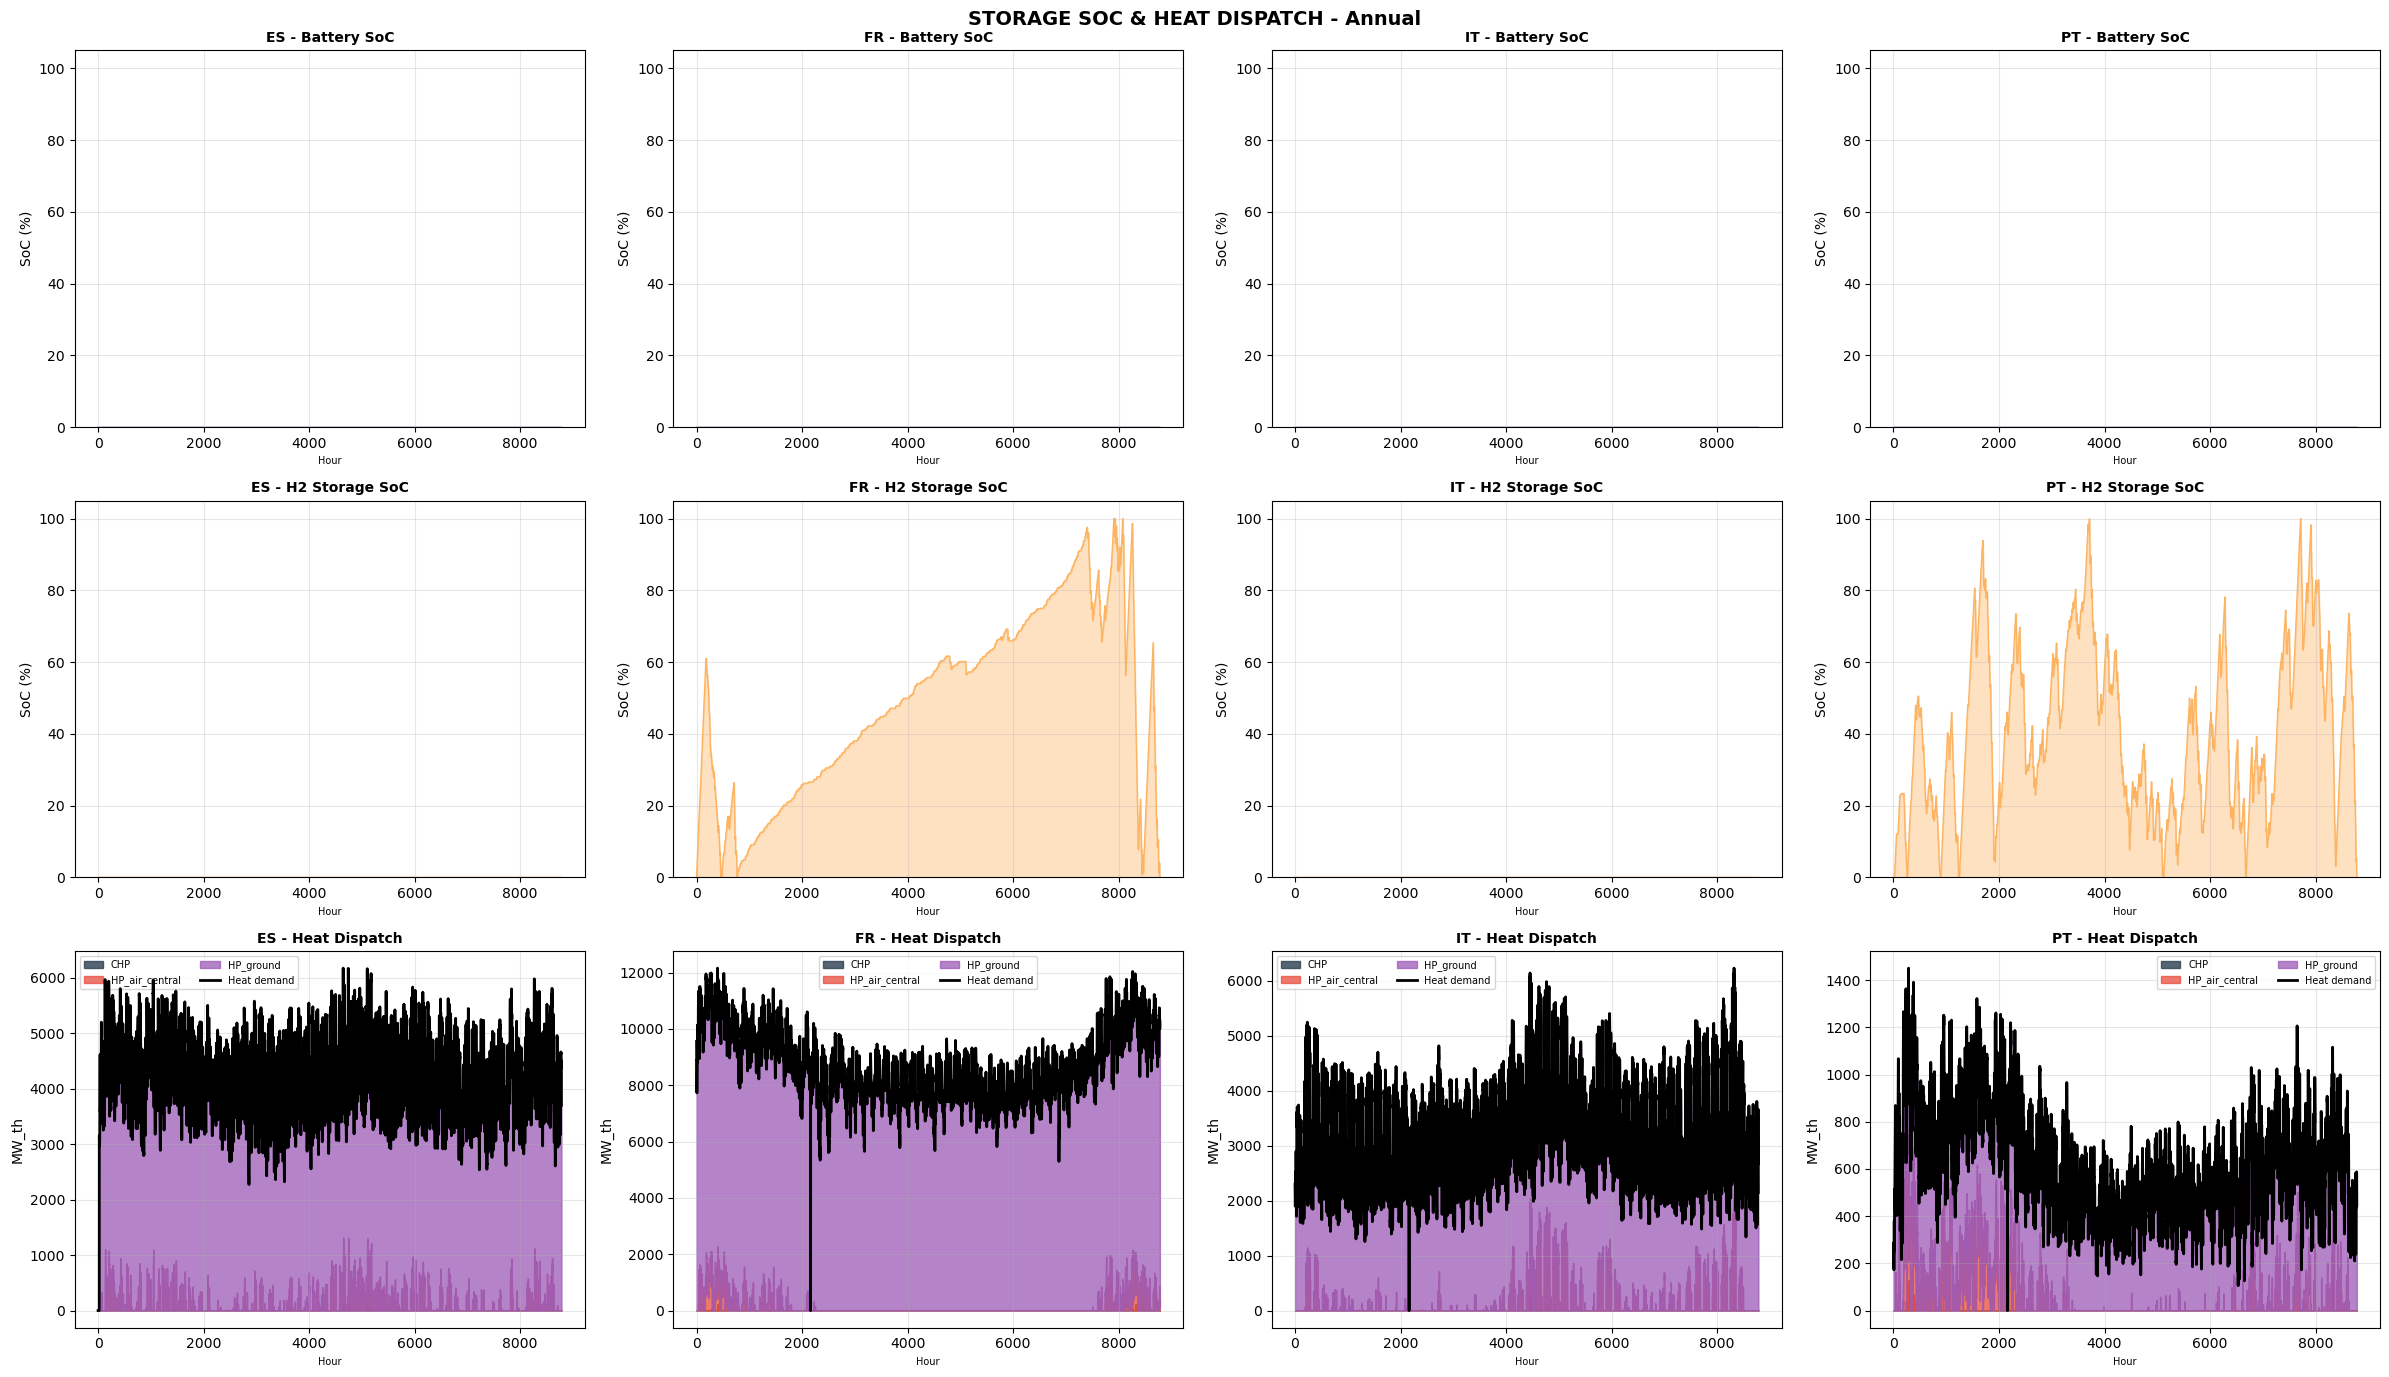

Saved: Plots/5_Storage_and_Heat_Dispatch.png


In [26]:
# =========================================================================
# PLOT: STORAGE STATE OF CHARGE + HEAT DISPATCH
# =========================================================================
import matplotlib.pyplot as plt
import numpy as np

hp_keys   = list(heat_pump_params_opt.keys())
HP_COLORS = {'HP_air_central':'#e74c3c','HP_air_decentral':'#e67e22','HP_ground':'#9b59b6'}
N = len(results_integrated_h2.countries)

fig, axes = plt.subplots(3, N, figsize=(6*N, 14))
if N == 1: axes = axes.reshape(3, 1)
fig.suptitle('STORAGE SOC & HEAT DISPATCH - Annual', fontsize=14, fontweight='bold')

for idx, country in enumerate(results_integrated_h2.countries):
    n_h  = len(results_integrated_h2.network.snapshots)
    hrs  = np.arange(n_h)
    soc_t = results_integrated_h2.network.storage_units_t
    batt_name, h2s_name = f"battery_{country}", f"h2_storage_{country}"
    bsoc = (soc_t.state_of_charge[batt_name].values if hasattr(soc_t,'state_of_charge') and batt_name in soc_t.state_of_charge.columns else np.zeros(n_h))
    hsoc = (soc_t.state_of_charge[h2s_name].values  if hasattr(soc_t,'state_of_charge') and h2s_name in soc_t.state_of_charge.columns  else np.zeros(n_h))
    caps = results_integrated_h2.storage_capacities[country]
    bpct = bsoc/max(caps.get('Battery_energy',1),1)*100
    hpct = hsoc/max(caps.get('H2_storage_energy',1),1)*100

    ax_b, ax_h, ax_ht = axes[0,idx], axes[1,idx], axes[2,idx]
    ax_b.fill_between(hrs, bpct, alpha=0.4, color='#BEAED4'); ax_b.plot(hrs, bpct, lw=1, color='#BEAED4')
    ax_b.set_title(f'{country} - Battery SoC', fontsize=10, fontweight='bold')
    ax_b.set_ylim(0,105); ax_b.set_ylabel('SoC (%)'); ax_b.grid(True, alpha=0.3)

    ax_h.fill_between(hrs, hpct, alpha=0.4, color='#FDB462'); ax_h.plot(hrs, hpct, lw=1, color='#FDB462')
    ax_h.set_title(f'{country} - H2 Storage SoC', fontsize=10, fontweight='bold')
    ax_h.set_ylim(0,105); ax_h.set_ylabel('SoC (%)'); ax_h.grid(True, alpha=0.3)

    heat_df = results_integrated_h2.heat_production_by_country[country]
    bot = np.zeros(n_h)
    chp_ht = heat_df['CHP_heat_output'].values if 'CHP_heat_output' in heat_df.columns else np.zeros(n_h)
    if chp_ht.any():
        ax_ht.fill_between(hrs, bot, bot+chp_ht, step='post', label='CHP', color='#2c3e50', alpha=0.80); bot+=chp_ht
    for hp_k in hp_keys:
        col = f'{hp_k}_heat_output'
        if col in heat_df.columns and heat_df[col].any():
            v = heat_df[col].values
            ax_ht.fill_between(hrs, bot, bot+v, step='post', label=hp_k, color=HP_COLORS.get(hp_k,'gray'), alpha=0.75); bot+=v
    dem = heat_df['demand_heat'].values if 'demand_heat' in heat_df.columns else np.zeros(n_h)
    ax_ht.plot(hrs, dem, 'k-', lw=2.0, label='Heat demand', zorder=10)
    ax_ht.set_title(f'{country} - Heat Dispatch', fontsize=10, fontweight='bold')
    ax_ht.set_ylabel('MW_th'); ax_ht.legend(fontsize=7, ncol=2); ax_ht.grid(True, alpha=0.3)
    for ax in [ax_b, ax_h, ax_ht]: ax.set_xlabel('Hour', fontsize=7)

plt.tight_layout()
import os; os.makedirs('Plots', exist_ok=True)
plt.savefig('Plots/5_Storage_and_Heat_Dispatch.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Plots/5_Storage_and_Heat_Dispatch.png")


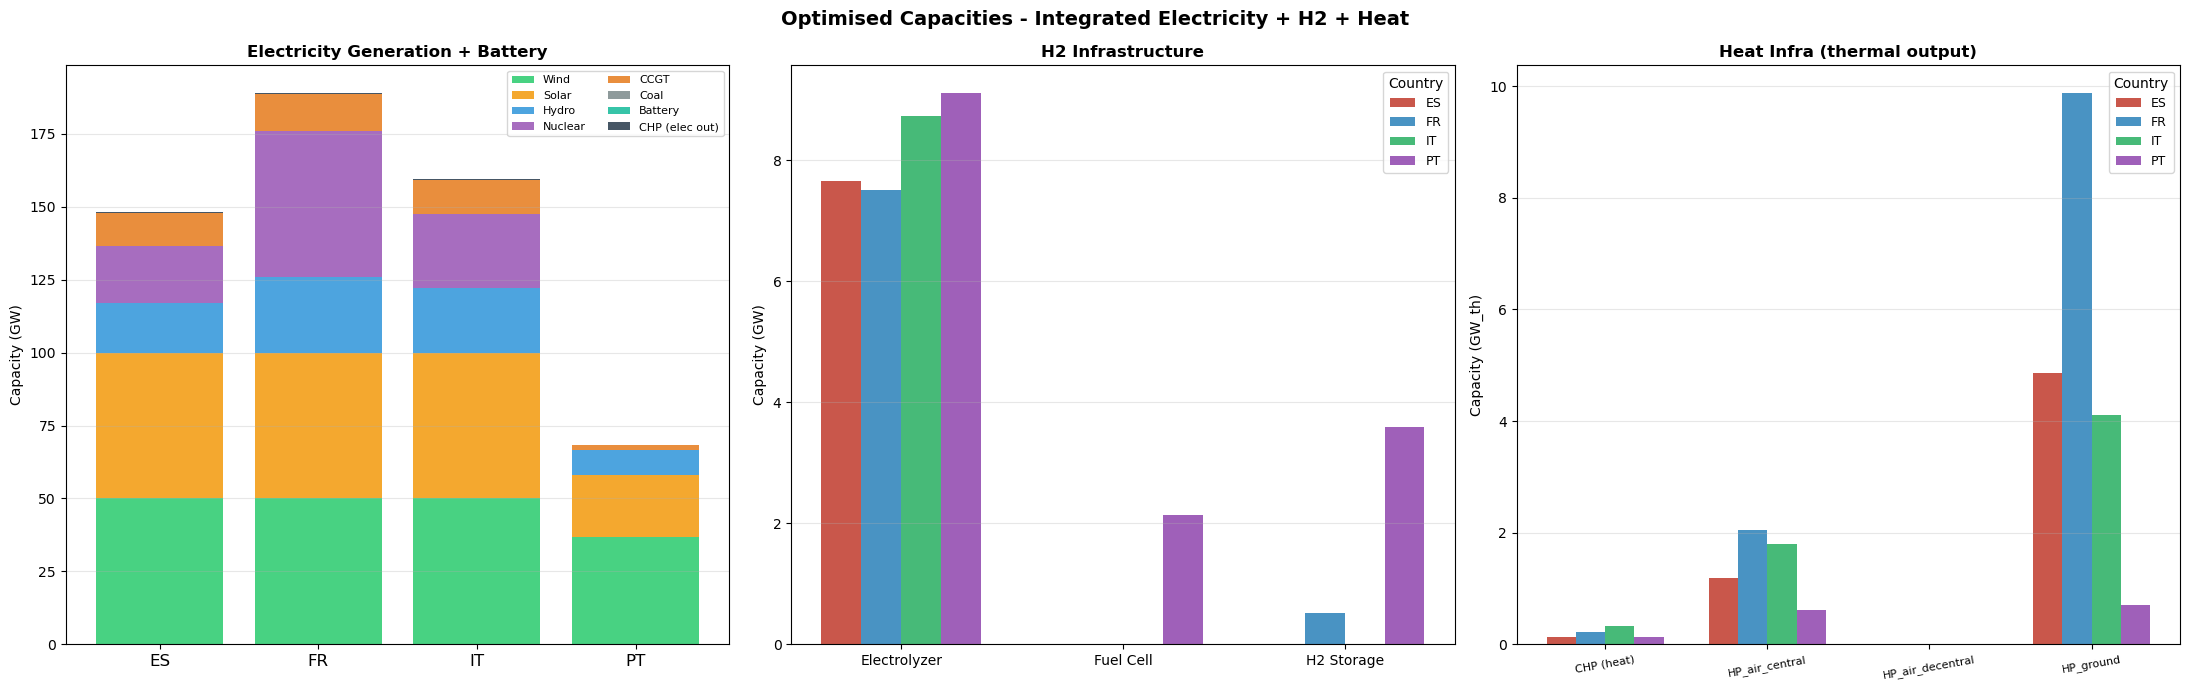

Saved: Plots/IH2H_01_Capacities.png


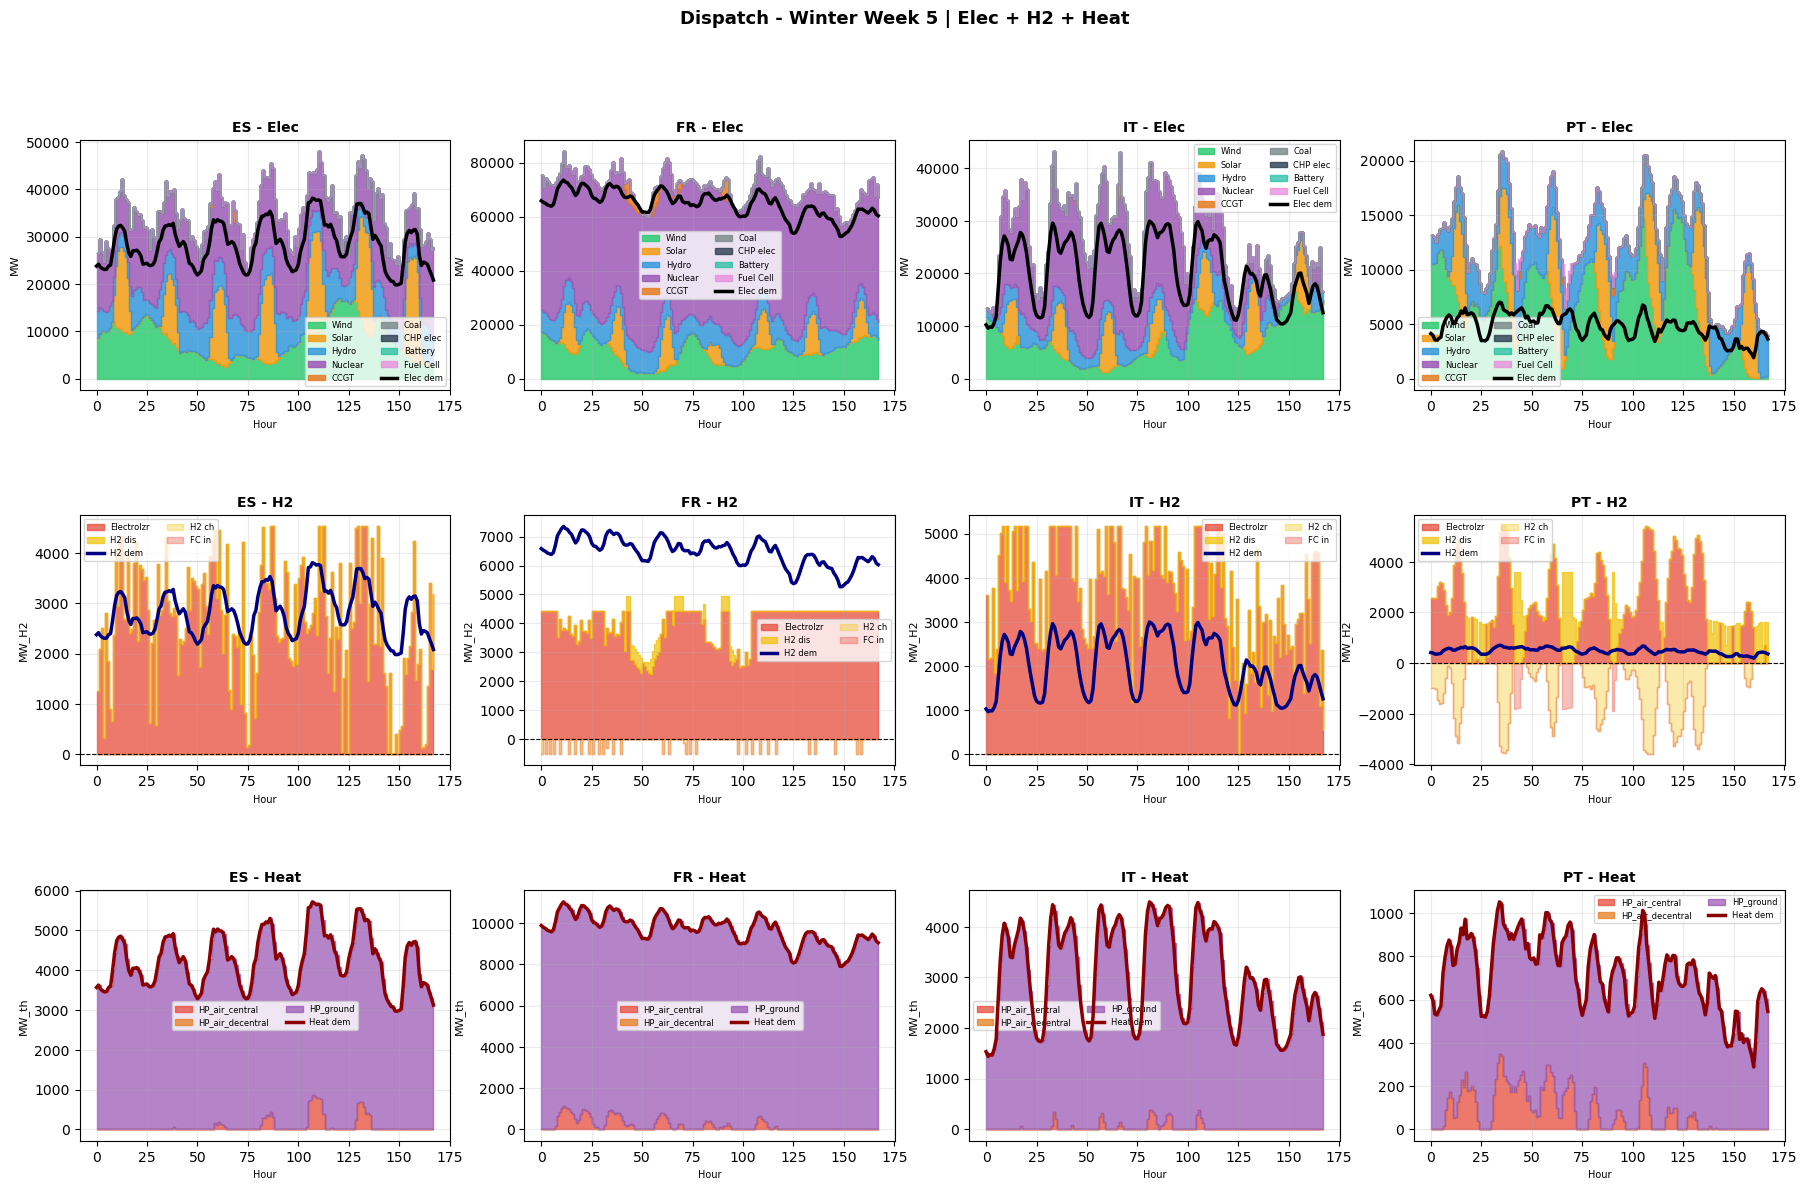

Saved: Plots/IH2H_02_Dispatch_Winter.png


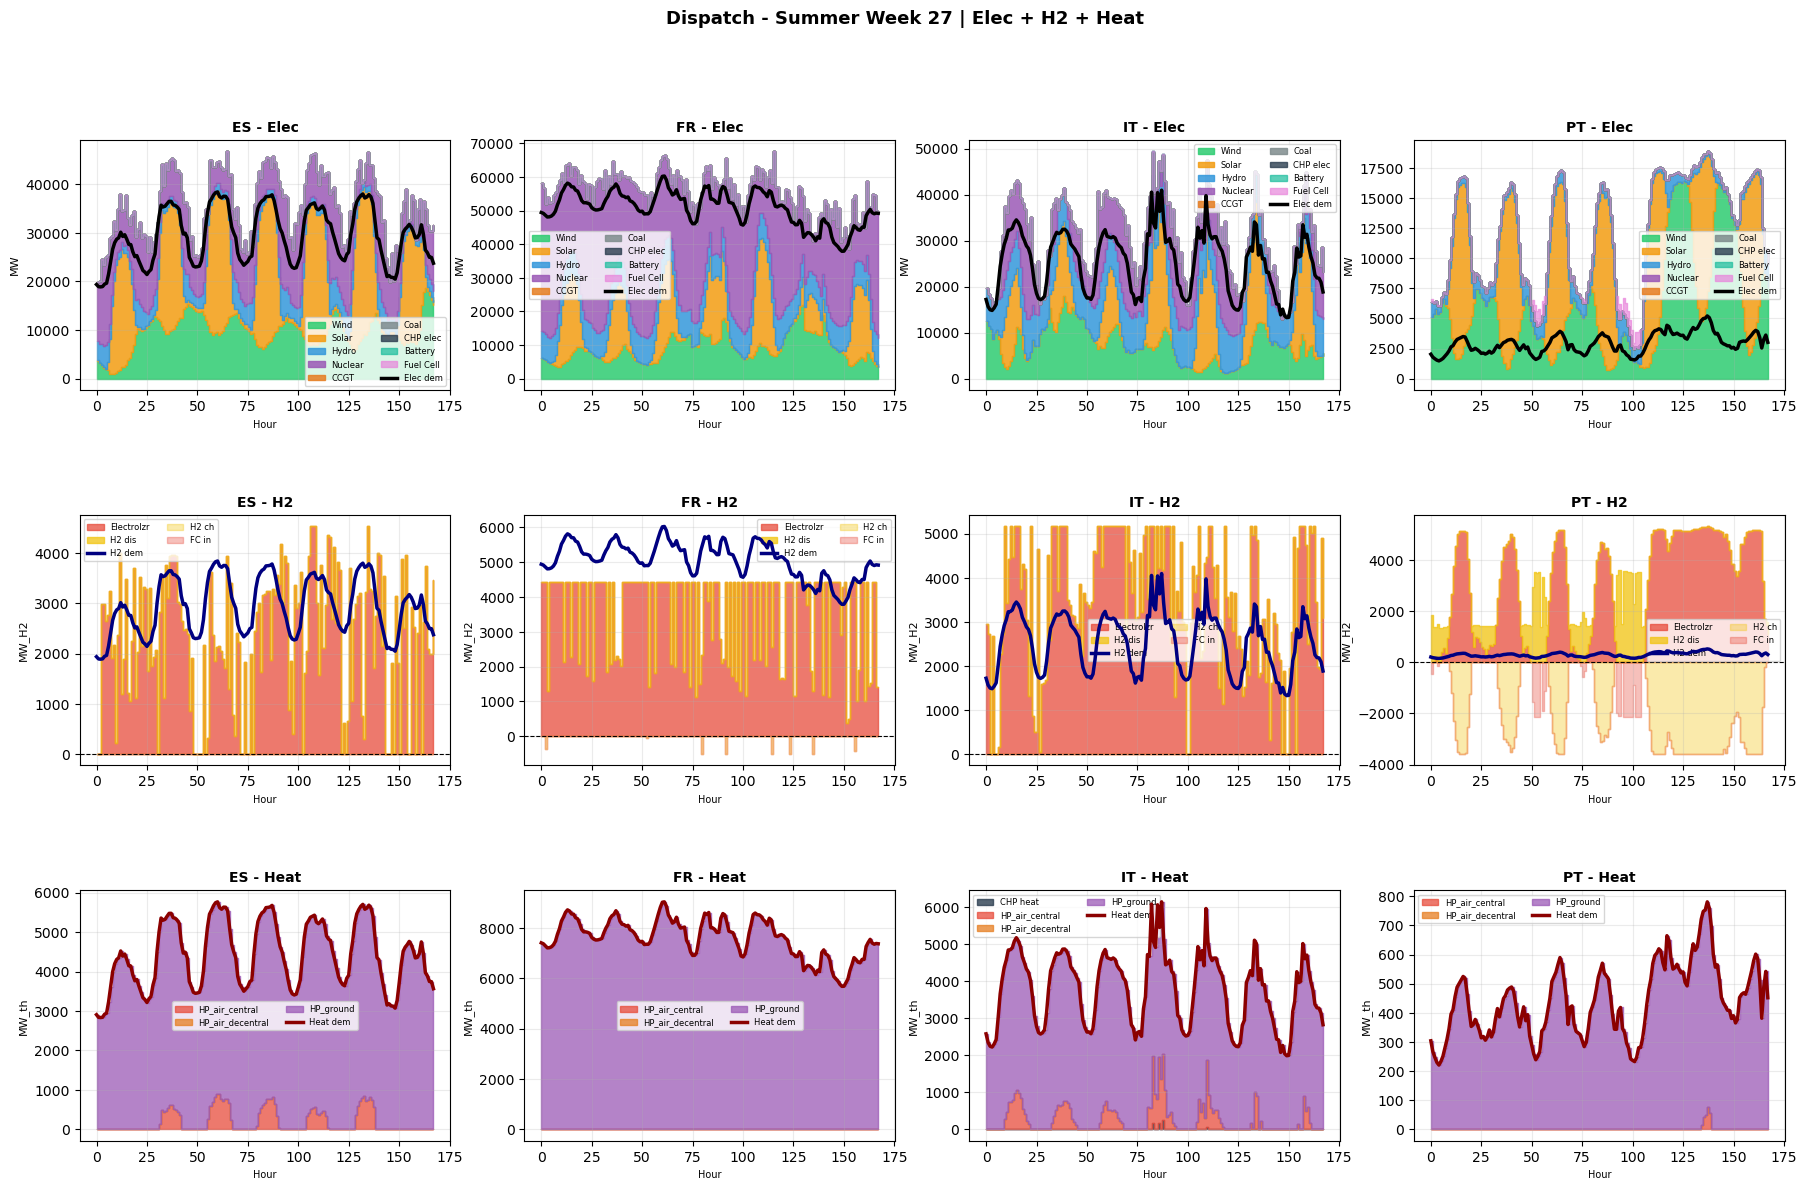

Saved: Plots/IH2H_02_Dispatch_Summer.png


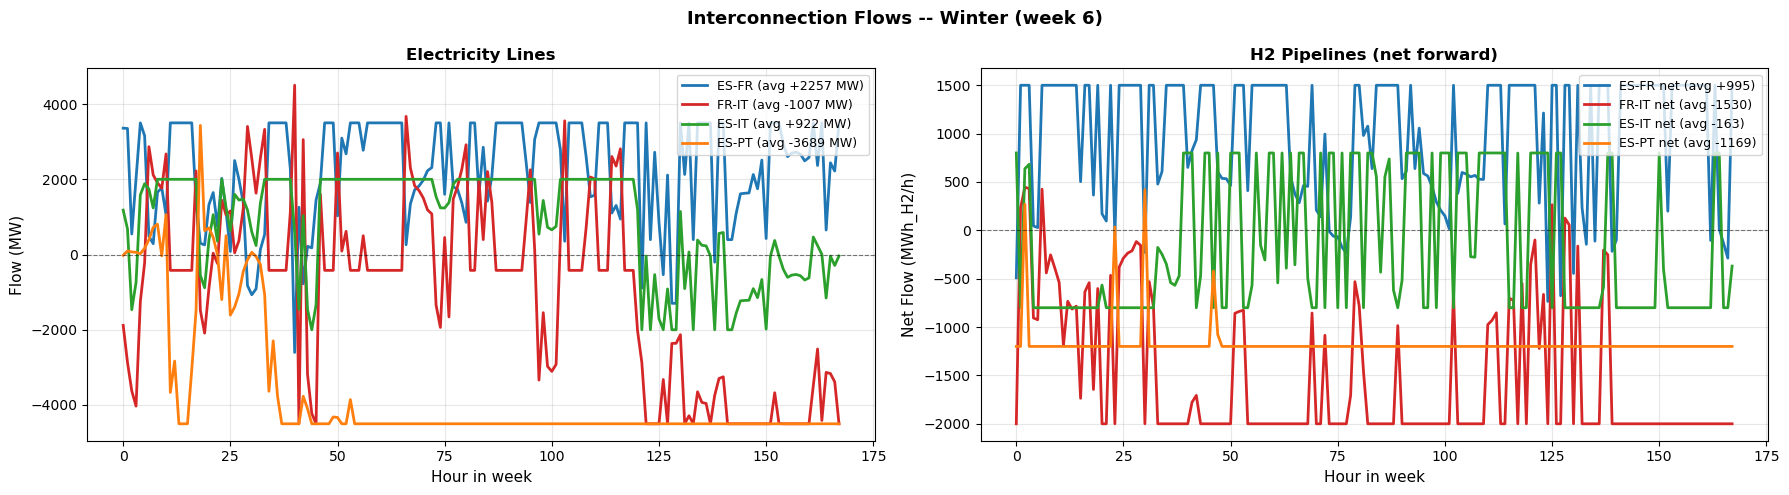

Saved: Plots/IH2_heat_03_Flows_Winter.png


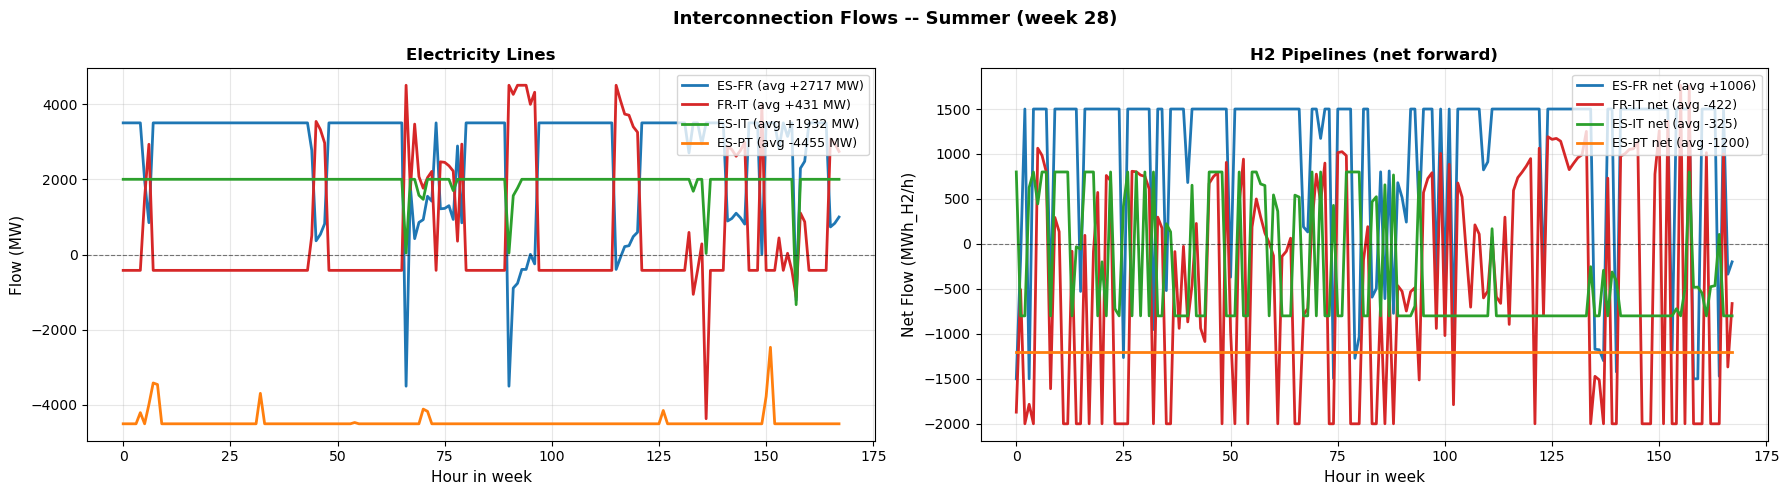

Saved: Plots/IH2_heat_03_Flows_Summer.png


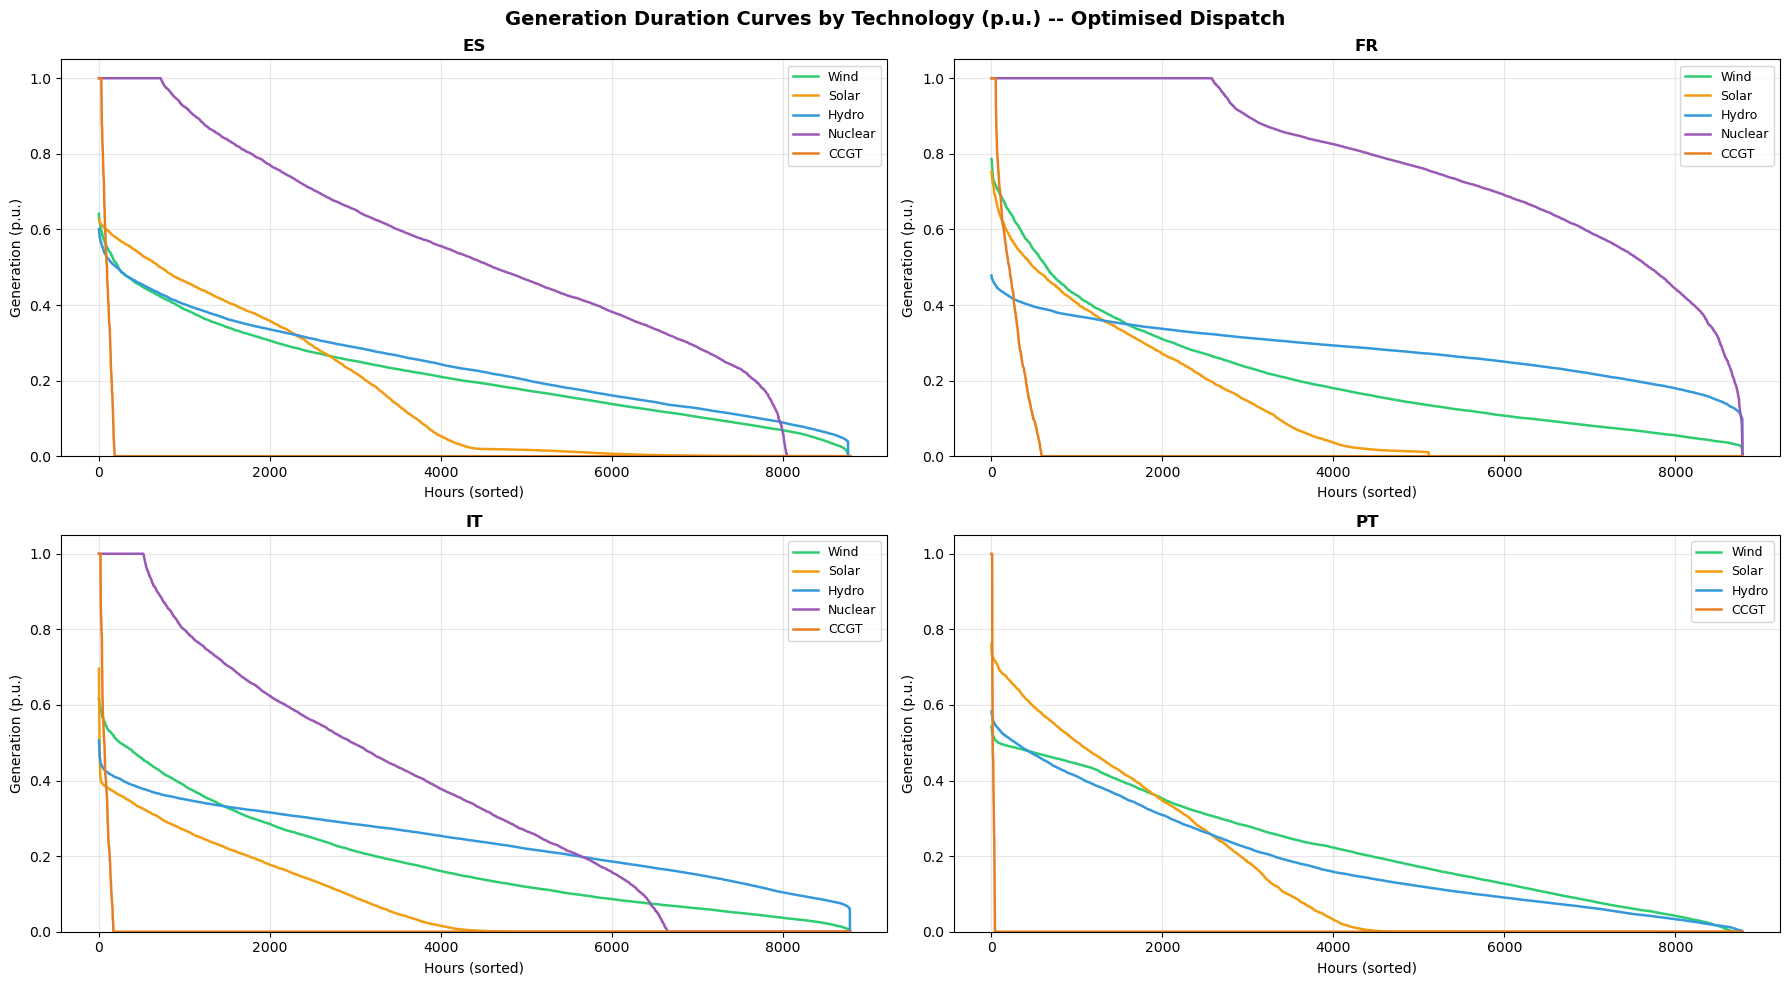

Saved: Plots/IH2_heat_04_GenDurationCurves.png


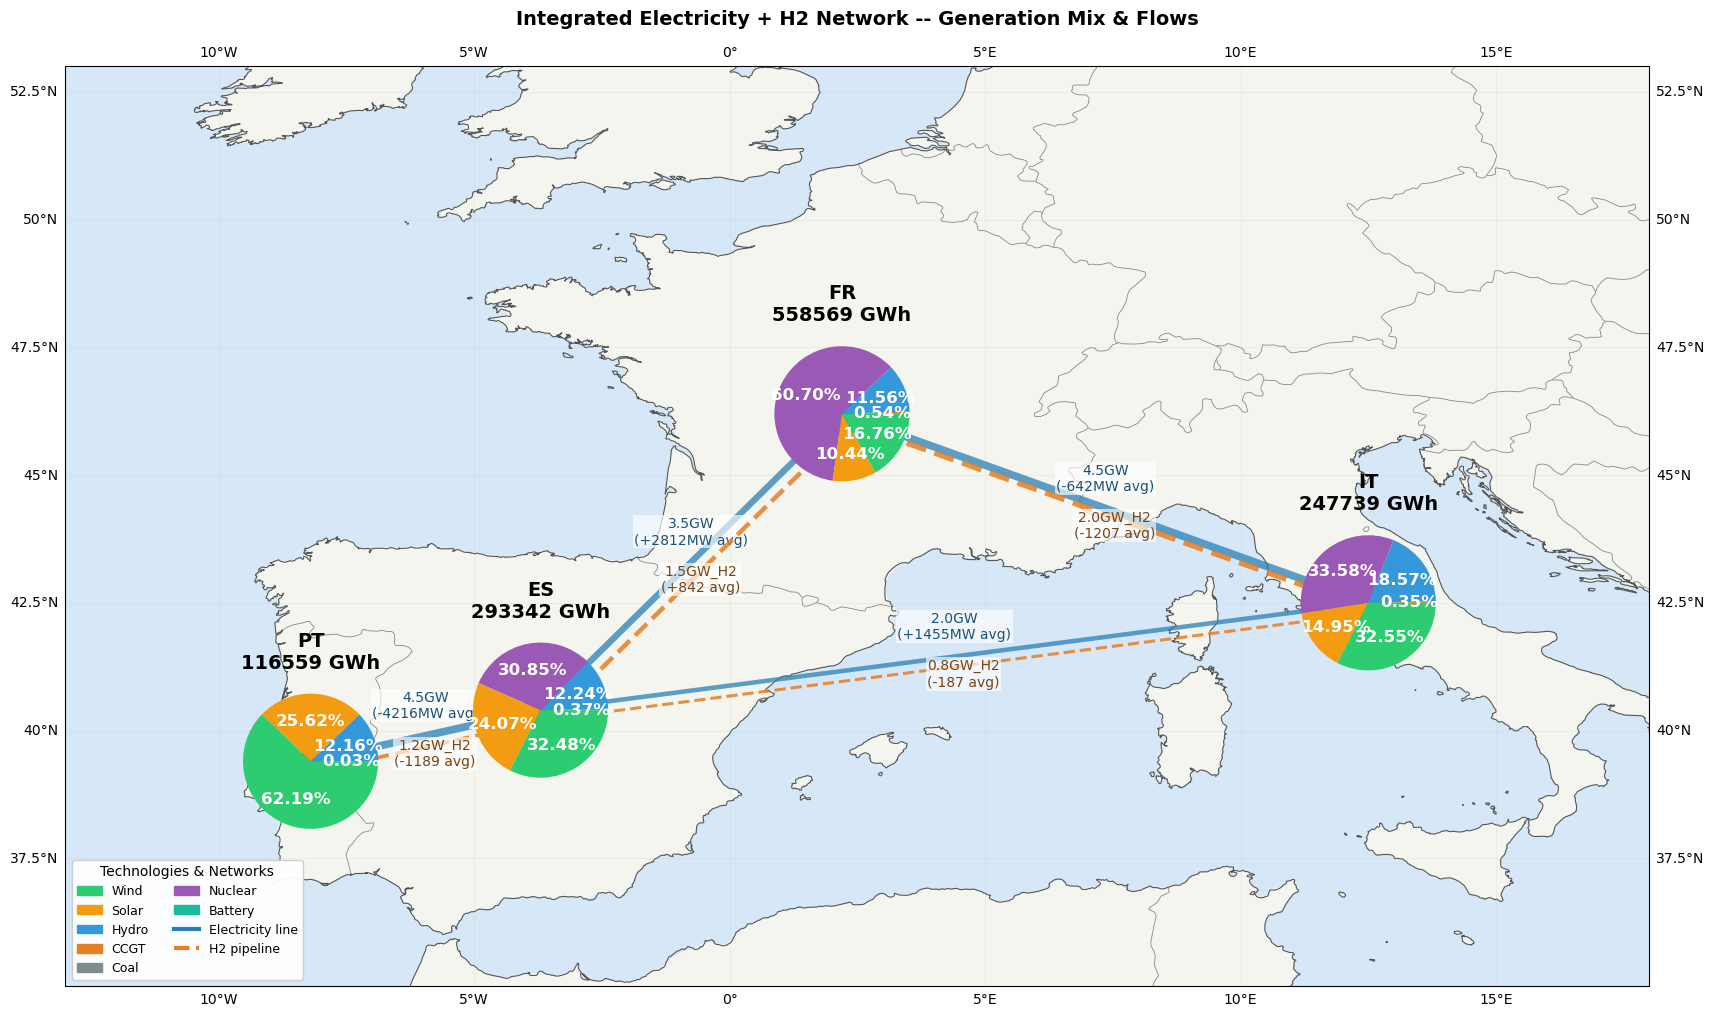

Saved: Plots/IH2_heat_05_Map.png


In [30]:
# =====================================================================
# PLOT 1 - OPTIMISED CAPACITIES (3 panels: elec, H2, heat)
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np
import os; os.makedirs('Plots', exist_ok=True)

res, network, COUNTRIES = results_integrated_h2, results_integrated_h2.network, results_integrated_h2.countries
hp_keys  = list(heat_pump_params_opt.keys())
_gen_df  = network.generators
_cap_col = 'p_nom_opt' if 'p_nom_opt' in _gen_df.columns else 'p_nom'

ELEC_C = {'Wind':'#2ecc71','Solar':'#f39c12','Hydro':'#3498db','CCGT':'#e67e22',
           'Coal':'#7f8c8d','Nuclear':'#9b59b6','Battery':'#1abc9c','CHP (elec out)':'#2c3e50'}
CC = {'ES':'#c0392b','FR':'#2980b9','IT':'#27ae60','PT':'#8e44ad'}
HPC = {'HP_air_central':'#e74c3c','HP_air_decentral':'#e67e22','HP_ground':'#9b59b6'}

elec_caps = {c:{} for c in COUNTRIES}
for gn, row in _gen_df.iterrows():
    if gn.startswith('gas_source_'): continue
    for c in COUNTRIES:
        if gn.startswith(f'gen_{c}_'):
            elec_caps[c][gn.replace(f'gen_{c}_','')] = row[_cap_col]
for c in COUNTRIES:
    elec_caps[c]['Battery'] = res.storage_capacities[c]['Battery_power']
    if res.storage_capacities[c].get('CHP_elec_cap',0) > 1:
        elec_caps[c]['CHP (elec out)'] = res.storage_capacities[c]['CHP_elec_cap']

h2i  = {c:{'Electrolyzer':res.storage_capacities[c]['Electrolyzer'],
            'Fuel Cell':res.storage_capacities[c]['Fuel_cell'],
            'H2 Storage':res.storage_capacities[c]['H2_storage_power']} for c in COUNTRIES}
hti  = {c:{'CHP (heat)':res.storage_capacities[c].get('CHP_heat_cap',0),
            **{hk:res.storage_capacities[c].get(f'{hk}_heat_cap',0) for hk in hp_keys}} for c in COUNTRIES}

_ORD = ['Wind','Solar','Hydro','Nuclear','CCGT','Coal','Battery','CHP (elec out)']
all_elec = sorted({t for d in elec_caps.values() for t in d}, key=lambda t:_ORD.index(t) if t in _ORD else len(_ORD))

fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(22,7))
fig.suptitle('Optimised Capacities - Integrated Electricity + H2 + Heat', fontsize=14, fontweight='bold')
xc = np.arange(len(COUNTRIES))
bot = np.zeros(len(COUNTRIES))
for tech in all_elec:
    v = [elec_caps[c].get(tech,0)/1e3 for c in COUNTRIES]
    ax1.bar(xc, v, bottom=bot, label=tech, color=ELEC_C.get(tech,'#bdc3c7'), alpha=0.88); bot += np.array(v)
ax1.set_xticks(xc); ax1.set_xticklabels(COUNTRIES, fontsize=12)
ax1.set_ylabel('Capacity (GW)'); ax1.set_title('Electricity Generation + Battery', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, ncol=2); ax1.grid(True, alpha=0.3, axis='y')

h2_lbl = ['Electrolyzer','Fuel Cell','H2 Storage']
xt = np.arange(len(h2_lbl)); w = 0.18
for i,c in enumerate(COUNTRIES):
    ax2.bar(xt+i*w, [h2i[c][t]/1e3 for t in h2_lbl], w, label=c, color=CC.get(c,'gray'), alpha=0.85)
ax2.set_xticks(xt+w*1.5); ax2.set_xticklabels(h2_lbl, fontsize=10)
ax2.set_ylabel('Capacity (GW)'); ax2.set_title('H2 Infrastructure', fontsize=12, fontweight='bold')
ax2.legend(title='Country', fontsize=9); ax2.grid(True, alpha=0.3, axis='y')

ht_lbl = ['CHP (heat)']+hp_keys
xh = np.arange(len(ht_lbl)); wh = 0.18
for i,c in enumerate(COUNTRIES):
    ax3.bar(xh+i*wh, [hti[c].get(t,0)/1e3 for t in ht_lbl], wh, label=c, color=CC.get(c,'gray'), alpha=0.85)
ax3.set_xticks(xh+wh*1.5); ax3.set_xticklabels(ht_lbl, fontsize=8, rotation=10)
ax3.set_ylabel('Capacity (GW_th)'); ax3.set_title('Heat Infra (thermal output)', fontsize=12, fontweight='bold')
ax3.legend(title='Country', fontsize=9); ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Plots/IH2H_01_Capacities.png', dpi=150, bbox_inches='tight'); plt.show()
print("Saved: Plots/IH2H_01_Capacities.png")

# -- PLOT 2: Dispatch weeks (elec + H2 + heat rows) -------------
TECH_C = {'Wind':'#2ecc71','Solar':'#f39c12','Hydro':'#3498db','CCGT':'#e67e22','Coal':'#7f8c8d','Nuclear':'#9b59b6'}
ORDERED = ['Wind','Solar','Hydro','Nuclear','CCGT','Coal']

for season, wk in [('Winter', 5), ('Summer', 27)]:
    h0, h1 = (wk-1)*168, wk*168
    x = np.arange(168)
    fig, axes = plt.subplots(3, len(COUNTRIES), figsize=(22, 13), gridspec_kw={'hspace':0.50})
    fig.suptitle(f'Dispatch - {season} Week {wk} | Elec + H2 + Heat', fontsize=13, fontweight='bold')
    for ci, country in enumerate(COUNTRIES):
        ae, ah, at_ = axes[0,ci], axes[1,ci], axes[2,ci]
        # Electricity
        be = np.zeros(168)
        for tech in ORDERED:
            gn = f'gen_{country}_{tech}'
            if gn in network.generators_t.p.columns:
                v = network.generators_t.p[gn].iloc[h0:h1].values
                ae.fill_between(x, be, be+v, step='post', label=tech, color=TECH_C.get(tech,'gray'), alpha=0.85); be+=v
        cl = f'chp_{country}'
        if cl in network.links_t.p1.columns:
            v = network.links_t.p1[cl].iloc[h0:h1].abs().values
            ae.fill_between(x, be, be+v, step='post', label='CHP elec', color='#2c3e50', alpha=0.80); be+=v
        bl = f'battery_{country}'
        if bl in network.storage_units_t.p.columns:
            v = network.storage_units_t.p[bl].iloc[h0:h1].clip(lower=0).values
            ae.fill_between(x, be, be+v, step='post', label='Battery', color='#1abc9c', alpha=0.70); be+=v
        fl = f'fuel_cell_{country}'
        if fl in network.links_t.p1.columns:
            v = network.links_t.p1[fl].iloc[h0:h1].abs().values
            ae.fill_between(x, be, be+v, step='post', label='Fuel Cell', color="#E885DB", alpha=0.70); be+=v
        dname = f'demand_elec_{country}'
        de = network.loads_t.p_set[dname].iloc[h0:h1].values if dname in network.loads_t.p_set.columns else np.zeros(168)
        ae.plot(x, de, 'k-', lw=2.5, label='Elec dem', zorder=10)
        ae.set_title(f'{country} - Elec', fontsize=10, fontweight='bold')
        ae.set_ylabel('MW', fontsize=8); ae.legend(fontsize=6, ncol=2); ae.grid(alpha=0.25)
        # H2
        el = f'electrolyzer_{country}'
        eh = network.links_t.p1[el].iloc[h0:h1].abs().values if el in network.links_t.p1.columns else np.zeros(168)
        hs = f'h2_storage_{country}'
        hd = network.storage_units_t.p[hs].iloc[h0:h1].clip(lower=0).values if hs in network.storage_units_t.p.columns else np.zeros(168)
        hc = network.storage_units_t.p[hs].iloc[h0:h1].clip(upper=0).abs().values if hs in network.storage_units_t.p.columns else np.zeros(168)
        fc_i = network.links_t.p0[fl].iloc[h0:h1].values if fl in network.links_t.p0.columns else np.zeros(168)
        dh2n = f'demand_h2_{country}'
        dh2 = network.loads_t.p_set[dh2n].iloc[h0:h1].values if dh2n in network.loads_t.p_set.columns else np.zeros(168)
        b2 = np.zeros(168)
        ah.fill_between(x, b2, b2+eh, step='post', label='Electrolzr', color='#e74c3c', alpha=0.75); b2+=eh
        ah.fill_between(x, b2, b2+hd, step='post', label='H2 dis', color='#f1c40f', alpha=0.75)
        ah.plot(x, dh2, color='navy', lw=2.5, label='H2 dem', zorder=10)
        ah.fill_between(x, -hc, step='post', label='H2 ch', color='#f1c40f', alpha=0.35)
        ah.fill_between(x, -hc-fc_i, -hc, step='post', label='FC in', color='#e74c3c', alpha=0.35)
        ah.axhline(0, color='k', lw=0.8, ls='--')
        ah.set_title(f'{country} - H2', fontsize=10, fontweight='bold')
        ah.set_ylabel('MW_H2', fontsize=8); ah.legend(fontsize=6, ncol=2); ah.grid(alpha=0.25)
        # Heat
        bh = np.zeros(168)
        cht = network.links_t.p2[cl].iloc[h0:h1].abs().values if cl in network.links_t.p2.columns else np.zeros(168)
        if cht.any():
            at_.fill_between(x, bh, bh+cht, step='post', label='CHP heat', color='#2c3e50', alpha=0.80); bh+=cht
        for hp_k in hp_keys:
            hl = f'hp_{hp_k}_{country}'
            if hl in network.links_t.p1.columns:
                hv = network.links_t.p1[hl].iloc[h0:h1].abs().values
                at_.fill_between(x, bh, bh+hv, step='post', label=hp_k, color=HPC.get(hp_k,'gray'), alpha=0.75); bh+=hv
        dhn = f'demand_heat_{country}'
        dht = network.loads_t.p_set[dhn].iloc[h0:h1].values if dhn in network.loads_t.p_set.columns else np.zeros(168)
        at_.plot(x, dht, color='darkred', lw=2.5, label='Heat dem', zorder=10)
        at_.set_title(f'{country} - Heat', fontsize=10, fontweight='bold')
        at_.set_ylabel('MW_th', fontsize=8); at_.legend(fontsize=6, ncol=2); at_.grid(alpha=0.25)
        for ax in [ae, ah, at_]: ax.set_xlabel('Hour', fontsize=7)
    fname = f'Plots/IH2H_02_Dispatch_{season}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
    print(f"Saved: {fname}")


# PLOT3
# =====================================================================
# PLOT 3 -- INTERCONNECTION FLOWS: ELECTRICITY vs H2 PIPELINES
# Side-by-side per season: electricity line flows (MW) | H2 net flows (MWh_H2/h)
# Same colour per route in both panels for easy comparison
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

res = results_integrated_h2

COLORS_ROUTE = {
    'ES-FR': '#1f77b4', 'ES-PT': '#ff7f0e',
    'ES-IT': '#2ca02c', 'FR-IT': '#d62728',
}

def week_of_hour(h): return int(h) // 168 + 1

elec_flows = res.power_flows.copy()
h2_flows   = res.h2_flows.copy()
elec_flows['week'] = elec_flows['hour'].apply(week_of_hour)
h2_flows['week']   = h2_flows['hour'].apply(week_of_hour)

for season_name, sel_week in [('Winter', 6), ('Summer', 28)]:
    ef = elec_flows[elec_flows['week'] == sel_week]
    hf = h2_flows[h2_flows['week']   == sel_week]

    fig, (ax_e, ax_h) = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle(
        f'Interconnection Flows -- {season_name} (week {sel_week})',
        fontsize=13, fontweight='bold'
    )

    # Electricity
    for from_c, to_c in ef[['from','to']].drop_duplicates().values:
        mask = (ef['from'] == from_c) & (ef['to'] == to_c)
        df   = ef[mask].sort_values('hour')
        rname = f'{from_c}-{to_c}'
        col   = COLORS_ROUTE.get(rname, COLORS_ROUTE.get(f'{to_c}-{from_c}', 'gray'))
        avg   = df['flow_mw'].mean()
        ax_e.plot(range(len(df)), df['flow_mw'].values, lw=2,
                  label=f'{rname} (avg {avg:+.0f} MW)', color=col)
    ax_e.axhline(0, color='black', ls='--', lw=0.8, alpha=0.5)
    ax_e.set_xlabel('Hour in week', fontsize=11); ax_e.set_ylabel('Flow (MW)', fontsize=11)
    ax_e.set_title('Electricity Lines', fontsize=12, fontweight='bold')
    ax_e.legend(fontsize=9, loc="upper right"); ax_e.grid(True, alpha=0.3)

    # H2 pipelines (net forward flow)
    for from_c, to_c in hf[['from','to']].drop_duplicates().values:
        mask = (hf['from'] == from_c) & (hf['to'] == to_c)
        df   = hf[mask].sort_values('hour')
        rname = f'{from_c}-{to_c}'
        col   = COLORS_ROUTE.get(rname, COLORS_ROUTE.get(f'{to_c}-{from_c}', 'gray'))
        net   = df['flow_mwh_h2_net'].values
        avg   = net.mean()
        ax_h.plot(range(len(df)), net, lw=2,
                  label=f'{rname} net (avg {avg:+.0f})', color=col)
    ax_h.axhline(0, color='black', ls='--', lw=0.8, alpha=0.5)
    ax_h.set_xlabel('Hour in week', fontsize=11)
    ax_h.set_ylabel('Net Flow (MWh_H2/h)', fontsize=11)
    ax_h.set_title('H2 Pipelines (net forward)', fontsize=12, fontweight='bold')
    ax_h.legend(fontsize=9,loc="upper right"); ax_h.grid(True, alpha=0.3)

    fname = f'Plots/IH2_heat_03_Flows_{season_name}.png'
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")


# PLOT4
# =====================================================================
# PLOT 4 -- GENERATION DURATION CURVES BY TECHNOLOGY (p.u.)
# Sorted descending generation profile for each tech, per country
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

res     = results_integrated_h2
network = res.network
COUNTRIES = res.countries

_gen_df  = network.generators
_cap_col = 'p_nom_opt' if 'p_nom_opt' in _gen_df.columns else 'p_nom'

TECH_COLORS = {
    'Wind': '#2ecc71', 'Solar': '#f39c12', 'Hydro': '#3498db',
    'CCGT': '#e67e22', 'Coal': '#7f8c8d', 'Nuclear': '#9b59b6',
}
ORDERED = ['Wind', 'Solar', 'Hydro', 'Nuclear', 'CCGT', 'Coal']

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Generation Duration Curves by Technology (p.u.) -- Optimised Dispatch',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for col, country in enumerate(COUNTRIES):
    ax = axes[col]
    for tech in ORDERED:
        gen_name = f'gen_{country}_{tech}'
        if gen_name not in network.generators_t.p.columns:
            continue
        cap = _gen_df.loc[gen_name, _cap_col] if gen_name in _gen_df.index else 0
        if cap <= 0:
            continue
        gen_vals = network.generators_t.p[gen_name].values
        pu = np.sort(gen_vals / cap)[::-1]
        ax.plot(pu, lw=1.8, label=tech, color=TECH_COLORS.get(tech, 'gray'))

    ax.set_title(f'{country}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Hours (sorted)', fontsize=10)
    ax.set_ylabel('Generation (p.u.)', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Plots/IH2_heat_04_GenDurationCurves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Plots/IH2_heat_04_GenDurationCurves.png")


# PLOT5
# =====================================================================
# PLOT 5 -- GEOGRAPHIC MAP: ELECTRICITY + H2 NETWORKS
# Blue solid lines  = electricity interconnections (width ~ NTC)
# Orange dashed lines = H2 pipelines (width ~ H2 capacity)
# Pie chart insets  = annual generation mix per country
# =====================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False

res     = results_integrated_h2
network = res.network
COUNTRIES = res.countries

COORDS = {'ES': (40.4, -3.7), 'FR': (46.2,  2.2),
          'IT': (42.5, 12.5), 'PT': (39.4, -8.2)}

TECH_COLORS = {
    'Wind': '#2ecc71', 'Solar': '#f39c12', 'Hydro': '#3498db',
    'CCGT': '#e67e22', 'Coal': '#7f8c8d', 'Nuclear': '#9b59b6',
    'Battery': '#1abc9c',
}
COUNTRY_COLORS = {'ES': '#c0392b', 'FR': '#2980b9', 'IT': '#27ae60', 'PT': '#8e44ad'}

_gen_df  = network.generators
_cap_col = 'p_nom_opt' if 'p_nom_opt' in _gen_df.columns else 'p_nom'

# Annual generation per country per tech
annual_gen = {c: {} for c in COUNTRIES}
for gen_name in _gen_df.index:
    for c in COUNTRIES:
        if gen_name.startswith(f'gen_{c}_'):
            tech = gen_name.replace(f'gen_{c}_', '')
            if gen_name in network.generators_t.p.columns:
                annual_gen[c][tech] = network.generators_t.p[gen_name].sum()

# Interconnection NTC (MW) and H2 pipeline capacities (MW_H2)
ELEC_LINES = [('ES','FR',3500), ('FR','IT',4500), ('ES','IT',2000), ('ES','PT',4500)]
H2_CAPS = {}
for name, row in network.links.iterrows():
    if name.startswith('h2_pipe_'):
        parts = name.split('_')
        from_c, to_c = parts[2], parts[3]
        H2_CAPS[(from_c, to_c)] = row['p_nom']

# Mean hourly flows
elec_net = {(f, t): grp['flow_mw'].mean()
            for (f, t), grp in res.power_flows.groupby(['from','to'])}
h2_net   = {(f, t): grp['flow_mwh_h2_net'].mean()
            for (f, t), grp in res.h2_flows.groupby(['from','to'])}

if HAS_CARTOPY:
    proj = ccrs.PlateCarree()
    fig  = plt.figure(figsize=(18, 13))
    ax   = fig.add_axes([0.05, 0.05, 0.88, 0.88], projection=proj)
    ax.set_extent([-13, 18, 35, 53], crs=proj)
    ax.add_feature(cfeature.LAND,   facecolor='#f5f5f0')
    ax.add_feature(cfeature.OCEAN,  facecolor='#d6e8f7')
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='#888')
    ax.coastlines(resolution='10m', linewidth=0.8, color='#555')
    ax.gridlines(draw_labels=True, alpha=0.2, linewidth=0.5)

    # Electricity lines (blue solid, width ~ NTC)
    for from_c, to_c, ntc in ELEC_LINES:
        if from_c not in COORDS or to_c not in COORDS: continue
        lat1, lon1 = COORDS[from_c]; lat2, lon2 = COORDS[to_c]
        lw  = 1.5 + 4 * ntc / 4500
        avg = elec_net.get((from_c, to_c), elec_net.get((to_c, from_c), 0))
        ax.plot([lon1, lon2], [lat1, lat2], color='#2980b9', lw=lw,
                alpha=0.75, transform=proj, zorder=3)
        mx, my = (lon1+lon2)/2, (lat1+lat2)/2
        ax.text(mx, my+0.35, f'{ntc/1e3:.1f}GW\n({avg:+.0f}MW avg)',
                transform=proj, fontsize=10, ha='center', color='#1a5276',
                bbox=dict(facecolor='white', alpha=0.65, pad=1, edgecolor='none'))

    # H2 pipelines (orange dashed, width ~ H2 cap, slightly offset)
    drawn = set()
    for (from_c, to_c), cap in H2_CAPS.items():
        key = tuple(sorted([from_c, to_c]))
        if key in drawn or from_c not in COORDS or to_c not in COORDS: continue
        drawn.add(key)
        lat1, lon1 = COORDS[from_c]; lat2, lon2 = COORDS[to_c]
        lw  = 1.0 + 3 * cap / 2000
        off = 0.18
        net = h2_net.get((from_c, to_c), h2_net.get((to_c, from_c), 0))
        ax.plot([lon1+off, lon2+off], [lat1-off, lat2-off],
                color='#e67e22', lw=lw, ls='--', alpha=0.85,
                transform=proj, zorder=3)
        mx, my = (lon1+lon2)/2+off, (lat1+lat2)/2-off
        ax.text(mx, my-0.4, f'{cap/1e3:.1f}GW_H2\n({net:+.0f} avg)',
                transform=proj, fontsize=10, ha='center', color='#784212',
                bbox=dict(facecolor='white', alpha=0.65, pad=1, edgecolor='none'))

    # Country nodes
    for c in COUNTRIES:
        if c not in COORDS: continue
        lat, lon = COORDS[c]
        total = sum(_gen_df.loc[n, _cap_col]
                    for n in _gen_df.index if n.startswith(f'gen_{c}_'))
        ms = 12 + 22 * total / 200e3
        ax.plot(lon, lat, 'o', markersize=ms, color=COUNTRY_COLORS.get(c,'gray'),
                transform=proj, zorder=5, markeredgecolor='white', markeredgewidth=2)
        #ax.text(lon, lat+1.3, c, transform=proj, fontsize=13,
               # fontweight='bold', ha='center')

    # Pie chart insets at country nodes
    ax_pos = ax.get_position()
    LON_MIN, LON_MAX, LAT_MIN, LAT_MAX = -13, 18, 35, 53
    SZ = 0.13

    for c in COUNTRIES:
        if c not in COORDS or not annual_gen[c]: continue
        lat, lon = COORDS[c]
        rel_x = (lon - LON_MIN) / (LON_MAX - LON_MIN)
        rel_y = (lat - LAT_MIN) / (LAT_MAX - LAT_MIN)
        fx = ax_pos.x0 + rel_x * ax_pos.width  - SZ / 2
        fy = ax_pos.y0 + rel_y * ax_pos.height - SZ / 2
        ax_i = fig.add_axes([fx, fy, SZ, SZ])
        data = {t: v for t, v in annual_gen[c].items() if v > 0}
        if not data: continue
        _, _, auts = ax_i.pie(
            list(data.values()),
            colors=[TECH_COLORS.get(t,'#bdc3c7') for t in data],
            autopct='%3.2f%%', textprops={'fontsize': 8}
        )
        for at in auts:
            at.set_color('white'); at.set_fontweight('bold'); at.set_fontsize(12)
        gwh = sum(data.values()) / 1e3
        ax_i.set_title(f'{c}\n{gwh:.0f} GWh', fontsize=14, fontweight='bold')

    # Legend
    tech_p = [mpatches.Patch(color=TECH_COLORS.get(t,'gray'), label=t)
              for t in ['Wind','Solar','Hydro','CCGT','Coal','Nuclear','Battery']]
    el_ln  = mlines.Line2D([], [], color='#2980b9', lw=3, label='Electricity line')
    h2_ln  = mlines.Line2D([], [], color='#e67e22', lw=3, ls='--', label='H2 pipeline')
    ax.legend(handles=tech_p + [el_ln, h2_ln], loc='lower left',
              fontsize=9, framealpha=0.95, ncol=2,
              title='Technologies & Networks', title_fontsize=10)
    ax.set_title('Integrated Electricity + H2 Network -- Generation Mix & Flows',
                 fontsize=14, fontweight='bold', pad=15)

else:
    # Schematic fallback if cartopy not installed
    fig, ax = plt.subplots(figsize=(10, 8))
    POS = {'ES': (0.22, 0.38), 'FR': (0.52, 0.72), 'IT': (0.78, 0.40), 'PT': (0.06, 0.28)}
    for from_c, to_c, ntc in ELEC_LINES:
        x1,y1 = POS[from_c]; x2,y2 = POS[to_c]
        ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle='->', color='#2980b9', lw=2))
    for (from_c, to_c), cap in H2_CAPS.items():
        x1,y1 = POS.get(from_c,(0,0)); x2,y2 = POS.get(to_c,(0,0))
        ax.plot([x1,x2],[y1,y2], '--', color='#e67e22', lw=2, alpha=0.7)
    for c, (x,y) in POS.items():
        ax.text(x, y, c, ha='center', va='center', fontsize=18, fontweight='bold',
                color=COUNTRY_COLORS.get(c,'gray'),
                bbox=dict(boxstyle='circle,pad=0.5', facecolor='white', edgecolor='gray'))
    el_ln = mlines.Line2D([],[],color='#2980b9', label='Electricity lines')
    h2_ln = mlines.Line2D([],[],color='#e67e22', ls='--', label='H2 pipelines')
    ax.legend(handles=[el_ln, h2_ln], fontsize=11)
    ax.set_title('Integrated Network (schematic -- install cartopy for map)', fontsize=12)
    ax.axis('off')

plt.savefig('Plots/IH2_heat_05_Map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Plots/IH2_heat_05_Map.png")
